<a href="https://colab.research.google.com/github/jmontseny/espec_ADD/blob/main/Sprint%209/sprint9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sqlalchemy import create_engine
import pymysql
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.ticker import StrMethodFormatter
from matplotlib.ticker import FuncFormatter
import seaborn as sns

pd.options.display.float_format = '{:.2f}'.format

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display

# Caso de negocio: análisis de ventas y comportamiento de clientes
## Contexto

La empresa dispone de un histórico de transacciones comerciales y de información relacionada con clientes, productos y compañías vendedoras.

El equipo de Ventas quiere comprender mejor la evolución del negocio, identificar patrones de comportamiento y detectar posibles riesgos y oportunidades que permitan mejorar la facturación, la captación y la fidelización de clientes.

Tu papel como analista de datos será transformar la información disponible en insights accionables para el negocio, identificando patrones relevantes, posibles anomalías y áreas que requieran atención. El objetivo no es únicamente describir los datos, sino entender qué implican los resultados para la actividad comercial.

In [3]:
# Nos conectamos a la base de datos de SQL introduciendo las claves de usuario

connection_string = "mysql+pymysql://%s:%s@%s:%s/%s" % (
    user,
    password,
    host,
    port,
    database
)

engine = create_engine(connection_string)

In [4]:
# Creamos un DataFrame por cada tabla de la base de datos

sql_tables = pd.read_sql("SHOW TABLES", engine)

for table in sql_tables.iloc[:, 0]:
    globals()[f"df_{table}"] = pd.read_sql(
        f"SELECT * FROM {table}",
        engine
    )

sql_tables

,Tables_in_transactions_db
0,companies
1,credit_card_status
2,credit_cards
3,products
4,transactions
5,users
6,vistamarketing


In [5]:
# Previsualizamos el DataFrame transactions

df_transactions.head(3)

,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,discount_amount,tax_amount,shipping_amount,channel,campaign_id,device_type,is_international,decline_reason,distance_km
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.20,1.44,34.17,72.25,0.00,online,SUMMER_TRAVEL,mobile,0,,59.95
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,"30, 11, 16, 81",2118,29.76,-95.38,16.10,22.47,0.00,store,SUMMER_TRAVEL,pos,1,,1157.10
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,175.00,0,72,2115,53.55,-113.50,1.05,14.45,0.00,store,NO_CAMPAIGN,pos,0,,540.32


In [6]:
# Creamos el DataFrame intermedio df_transactions_products

def explode_transactions(df_transactions):

    df_transactions_products = df_transactions[["id", "product_ids"]].copy()

    df_transactions_products["product_ids"] = (
        df_transactions_products["product_ids"]
        .str.split(r"\s*,\s*")
    )
    df_transactions_products = df_transactions_products.explode("product_ids").reset_index(drop=True)

    df_transactions_products = df_transactions_products.rename(columns={"id":"transaction_id","product_ids":"product_id"})

    df_transactions_products["product_id"] = (
        df_transactions_products["product_id"]
        .astype(int)
    )

    return df_transactions_products

In [7]:
df_transactions_products = explode_transactions(df_transactions)
df_transactions_products.head()

,transaction_id,product_id
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,16
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,26
2,00043A49-2949-494B-A5DD-A5BAE3BB19DD,97
3,00043A49-2949-494B-A5DD-A5BAE3BB19DD,87
4,00045D6B-ED2E-4F2F-8186-CEE074D875D0,30


# 1. Evolución y comportamiento de las ventas

La dirección comercial quiere conocer cómo ha evolucionado la actividad de ventas durante el periodo analizado.

## 1.1 Evolución temporal de las transacciones

Analiza la evolución del número de transacciones a lo largo del tiempo.

La dirección quiere saber:

Si el volumen de actividad ha crecido o disminuido.
Si existen periodos de crecimiento o contracción relevantes.
Si se observan cambios significativos en determinados años o periodos.
Si la evolución podría estar relacionada con acontecimientos externos o cambios en el comportamiento de los clientes.

¿Cómo ha evolucionado la actividad comercial a lo largo del tiempo y qué cambios relevantes podemos identificar?

In [8]:
df_transactions["year"] = (
    df_transactions["timestamp"].dt.year
)

transactions_year = (
    df_transactions
    .groupby("year")
    .agg(total_transactions=("id", "count"))
    .reset_index()
)

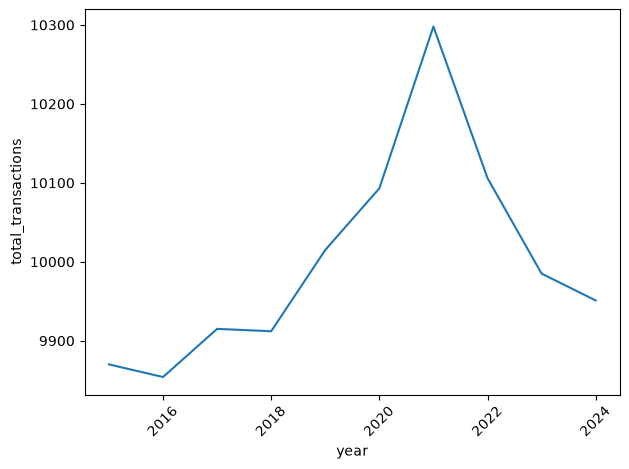

In [9]:
ax = sns.lineplot(
    data=transactions_year,
    x="year",
    y="total_transactions"
)

plt.xticks(rotation=45)

plt.tight_layout()

El número total de transacciones aumentó de forma progresiva entre 2016 y 2021. A partir de 2021 se observa un descenso acusado que continúa durante 2022 y 2023. En 2024 el volumen vuelve a disminuir, aunque de forma menos pronunciada que en los años anteriores.

Esta evolución coincide temporalmente con el periodo de la pandemia de COVID-19, por lo que una posible explicación sería un incremento excepcional de la actividad durante esos años seguido de una normalización posterior. No obstante, con los datos disponibles no es posible confirmar esta relación causal, por lo que esta interpretación debe considerarse únicamente una hipótesis.

También es posible que parte de los nuevos clientes captados durante ese periodo se hayan mantenido posteriormente, ya que el volumen final continúa siendo ligeramente superior al de los primeros años analizados.

In [10]:
df_transactions["year_month"] = (
    df_transactions["timestamp"]
    .dt.to_period("M")
    .astype(str)
)

transactions_month = (
    df_transactions
    .groupby("year_month")
    .agg(total_transactions=("id", "count"))
    .reset_index()
)

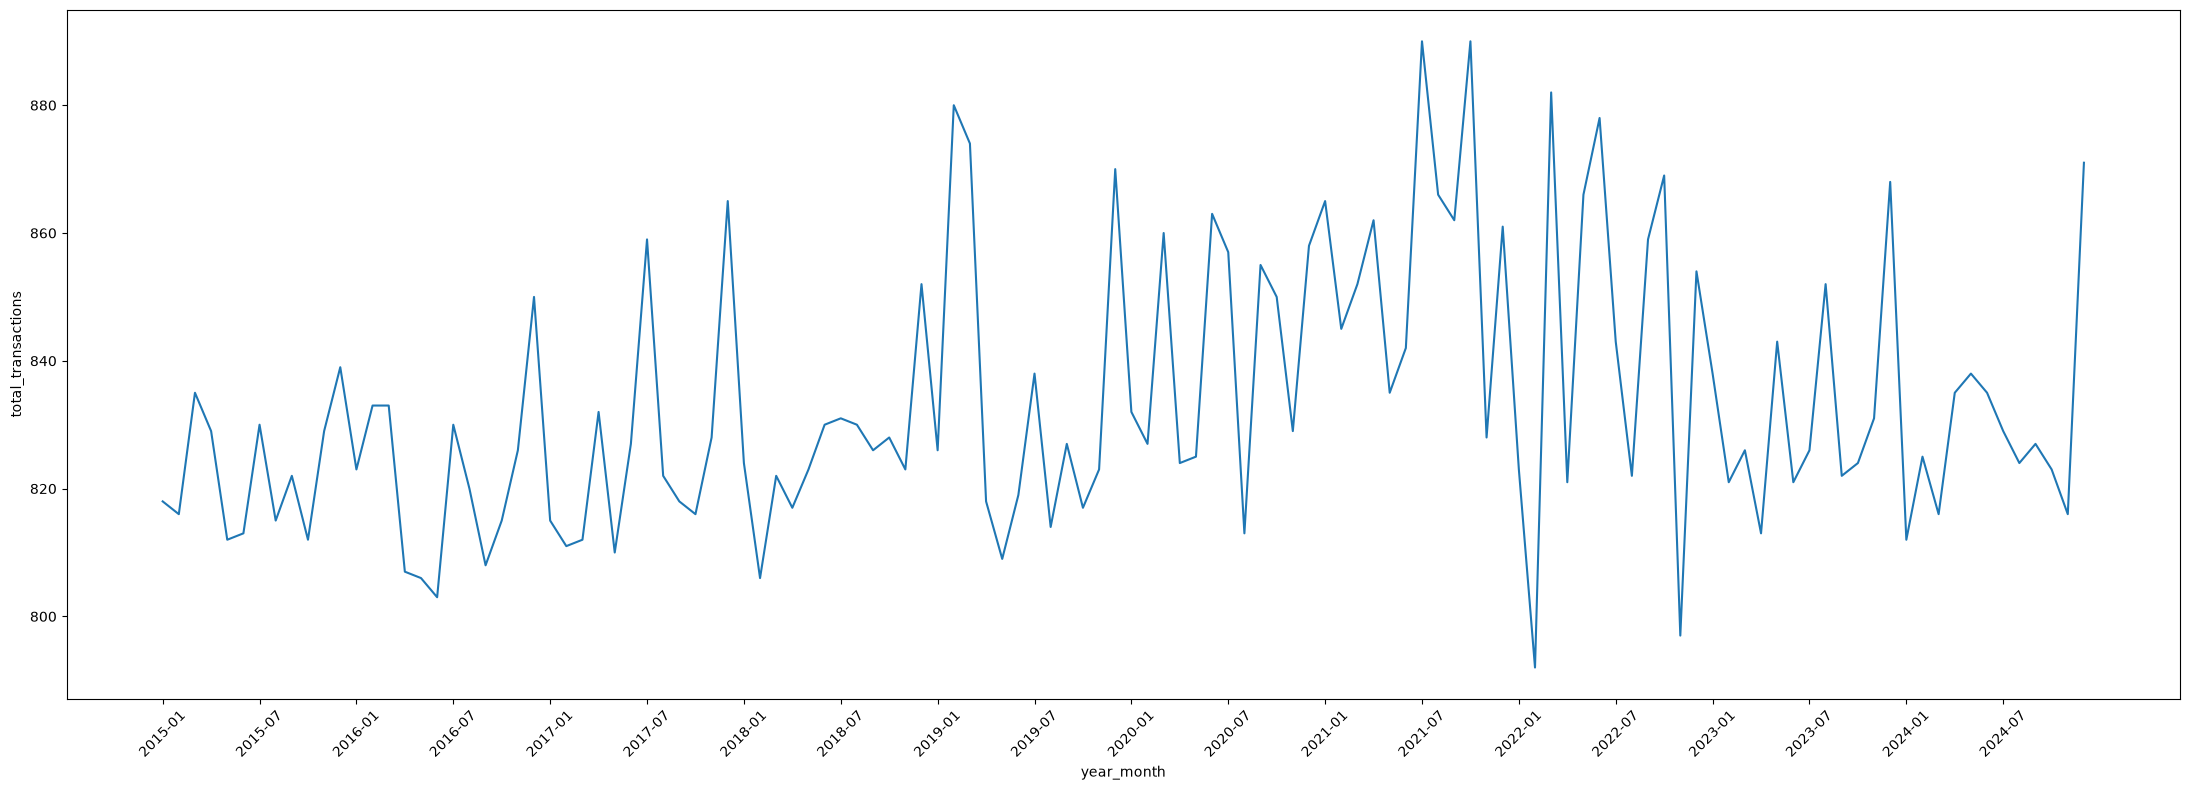

In [11]:
plt.figure(figsize=(22,8))

ax = sns.lineplot(
    data=transactions_month,
    x="year_month",
    y="total_transactions"
)

ticks = range(0, len(transactions_month), 6)

ax.set_xticks(ticks)
ax.set_xticklabels(
    transactions_month["year_month"].iloc[ticks],
    rotation=45
)

plt.tight_layout()

plt.show()

Al analizar la evolución mensual se observa una elevada variabilidad entre meses, con numerosos picos y descensos a lo largo de toda la serie temporal.

A simple vista no se aprecia un patrón estacional claro, es decir, no existen meses que presenten sistemáticamente un mayor o menor número de transacciones cada año. Para confirmar la existencia de estacionalidad sería conveniente comparar cada mes entre distintos años mediante una tabla dinámica o un gráfico que agrupe la información por año y mes.

Solución propuesta por la IA:

In [12]:
fig = px.line(
    transactions_month,
    x="year_month",
    y="total_transactions",
    title="Monthly Evolution of Total Transactions",
    labels={
        "year_month": "Year-Month",
        "total_transactions": "Total Transactions"
    }
)

fig.update_xaxes(
    dtick="M6",
    tickformat="%Y-%m",
    tickangle=45
)

fig.update_layout(hovermode="x unified")

fig.show()

En general el gráfico propuesto por la IA se ve como una mejora del gráfico de transacciones por mes. Por un lado se persenta con una cuadrícula de fondo, por lo que se hace más fácil alinear ejes y resultados en el gráfico. También se utiliza plotly, por lo que el gráfico es interactivo y se pueden ver resultados específicos maniobrando el cursor sobre la línea. Finalmente, el gráfico tiene mejor presencia ya que se ha mejorado con títulos que lo hacen más comprensible.

## 1.2 Clientes de mayor valor

El equipo comercial quiere identificar a los clientes que generan un mayor volumen de facturación.

El objetivo es detectar aquellos clientes que tienen un mayor peso económico para la compañía y determinar si existe una concentración relevante de ingresos en un grupo reducido de usuarios.

¿Qué clientes generan mayor valor económico para la empresa y qué importancia tienen dentro de la facturación global?

In [13]:
turnover = (
    df_transactions[df_transactions["declined"] == 0]
    .groupby("user_id")
    .agg(
        total_turnover=("amount","sum")
    )
    .sort_values(
        by="total_turnover",
        ascending=False
    )
    .reset_index()
)

turnover.head(15)

,user_id,total_turnover
0,289,47332.90
1,318,46393.44
2,455,40594.55
3,417,37393.91
4,185,34560.87
5,285,33217.28
6,454,29528.42
7,349,27835.38
8,193,27076.83
9,317,22484.76


<Axes: xlabel='user_id', ylabel='total_turnover'>

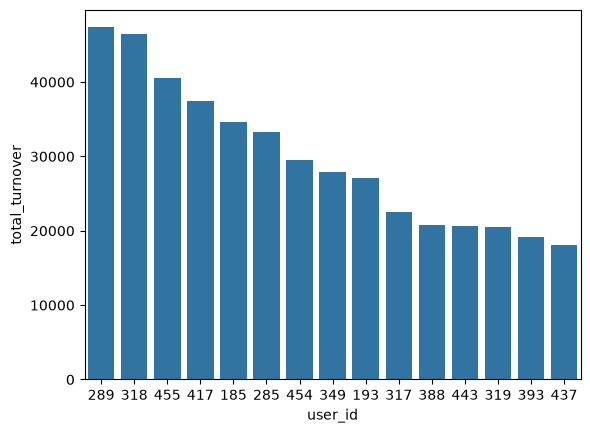

In [14]:
sns.barplot(
    data=turnover.head(15),
    x="user_id",
    y="total_turnover",
    order=turnover.head(15)["user_id"]
)

Los quince usuarios con mayor volumen de facturación acumulan importes comprendidos aproximadamente entre los 18.000 € y los 45.000 € durante el periodo analizado (2015-2024).

Si distribuimos este gasto a lo largo de los diez años disponibles, supone aproximadamente entre 1.800 € y 4.500 € anuales por usuario, lo que indica que se trata de clientes de alto valor para el negocio.

Sería interesante profundizar en el comportamiento de estos usuarios para determinar si su elevada facturación proviene de pocas compras de gran importe o, por el contrario, de un elevado número de compras repartidas a lo largo del tiempo. Esta información permitiría definir estrategias específicas de fidelización para este segmento.

Solución propuesta por la IA:

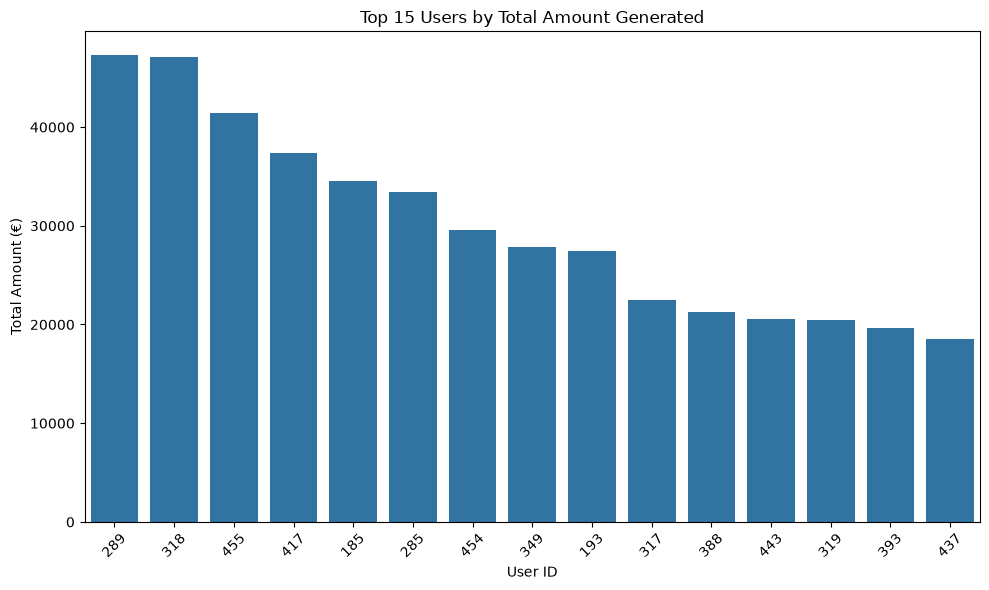

In [15]:
total_amount_by_user = (
    df_transactions
    .groupby('user_id')
    .agg(total_amount=('amount', 'sum'))
    .sort_values(by='total_amount', ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=total_amount_by_user.head(15),
    x='user_id',
    y='total_amount',
    order=total_amount_by_user.head(15)['user_id']
)
plt.title('Top 15 Users by Total Amount Generated')
plt.xlabel('User ID')
plt.ylabel('Total Amount (€)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La solución propuesta por la IA es igual a la que ya habíamos hecho, pero con un grave error, ya que no filtra por transacciones que no han sido rechazadas.

## 1.3 Importe de las transacciones y operaciones rechazadas

El equipo de Ventas y Operaciones quiere conocer si el importe de las transacciones varía según la hora del día y si existen diferencias entre las operaciones aceptadas y rechazadas.

El análisis debe permitir detectar comportamientos atípicos o diferencias que puedan justificar una investigación adicional.

¿Existen diferencias relevantes en el valor de las operaciones según la hora del día o su estado de aceptación/rechazo?

In [16]:
df_transactions['hour'] = df_transactions['timestamp'].dt.hour

In [17]:
df_transactions["declined"].value_counts()

declined
0    99111
1      888
Name: count, dtype: int64

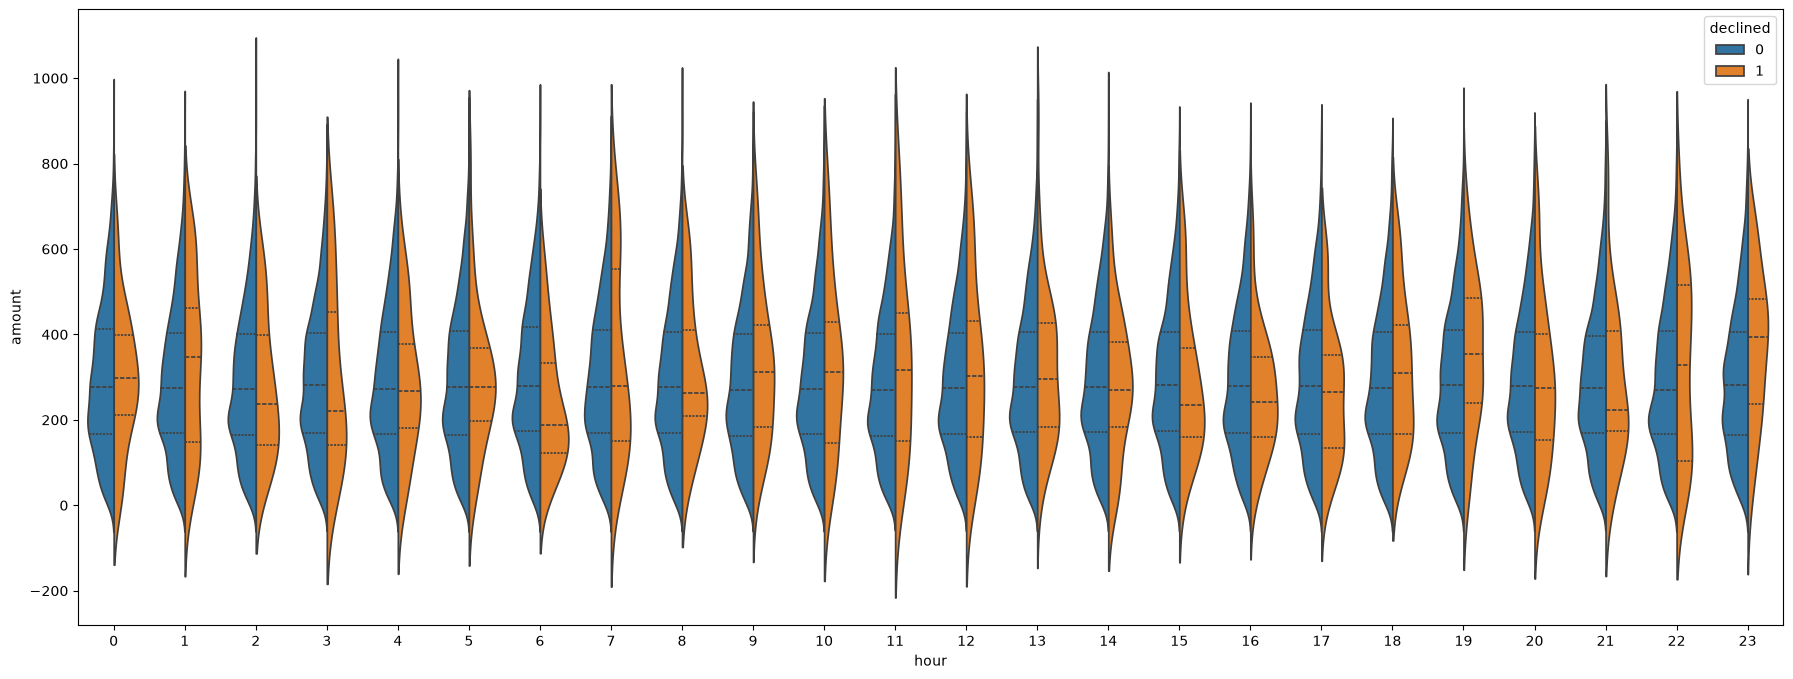

In [18]:
plt.figure(figsize=(22,8))

sns.violinplot(
    data=df_transactions,
    x="hour",
    y="amount",
    hue="declined",
    split=True,
    inner="quartile"
)

plt.show()

La distribución del importe de las transacciones aceptadas es relativamente estable a lo largo de las distintas horas del día y presenta una dispersión similar en la mayoría de los casos.

Las transacciones rechazadas muestran una distribución menos definida. Sin embargo, únicamente existen 888 transacciones rechazadas frente a más de 99.000 aceptadas, por lo que la diferencia observada probablemente esté influida por el reducido tamaño de esta muestra y debe interpretarse con cautela.

In [19]:
# Creamos franjas horarias para analizar los resultados

df_transactions["time_slot"] = pd.cut(
    df_transactions["hour"],
    bins=[-1, 5, 11, 17, 23],
    labels=["Midnight", "Morning", "Afternoon", "Evening"]
)

df_transactions[["hour", "time_slot"]].head(3)

,hour,time_slot
0,7,Morning
1,15,Afternoon
2,19,Evening


<Axes: xlabel='time_slot', ylabel='amount'>

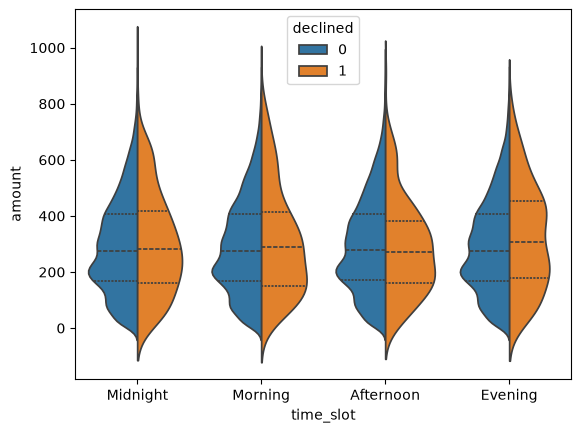

In [20]:
sns.violinplot(
    data=df_transactions,
    x="time_slot",
    y="amount",
    hue="declined",
    split=True,
    inner="quartile"
)

Al agrupar las horas en cuatro franjas (Madrugada, Mañana, Tarde y Noche), la distribución del importe continúa siendo muy similar entre todas ellas.

No se observan diferencias relevantes en el comportamiento de compra según la franja horaria, lo que indica que la actividad comercial se mantiene relativamente constante durante todo el día.

Desde un punto de vista operativo, estos resultados sugieren que no existe una única franja crítica de actividad y que el servicio debe ofrecer un rendimiento homogéneo durante las 24 horas.

Solución propuesta por la IA:

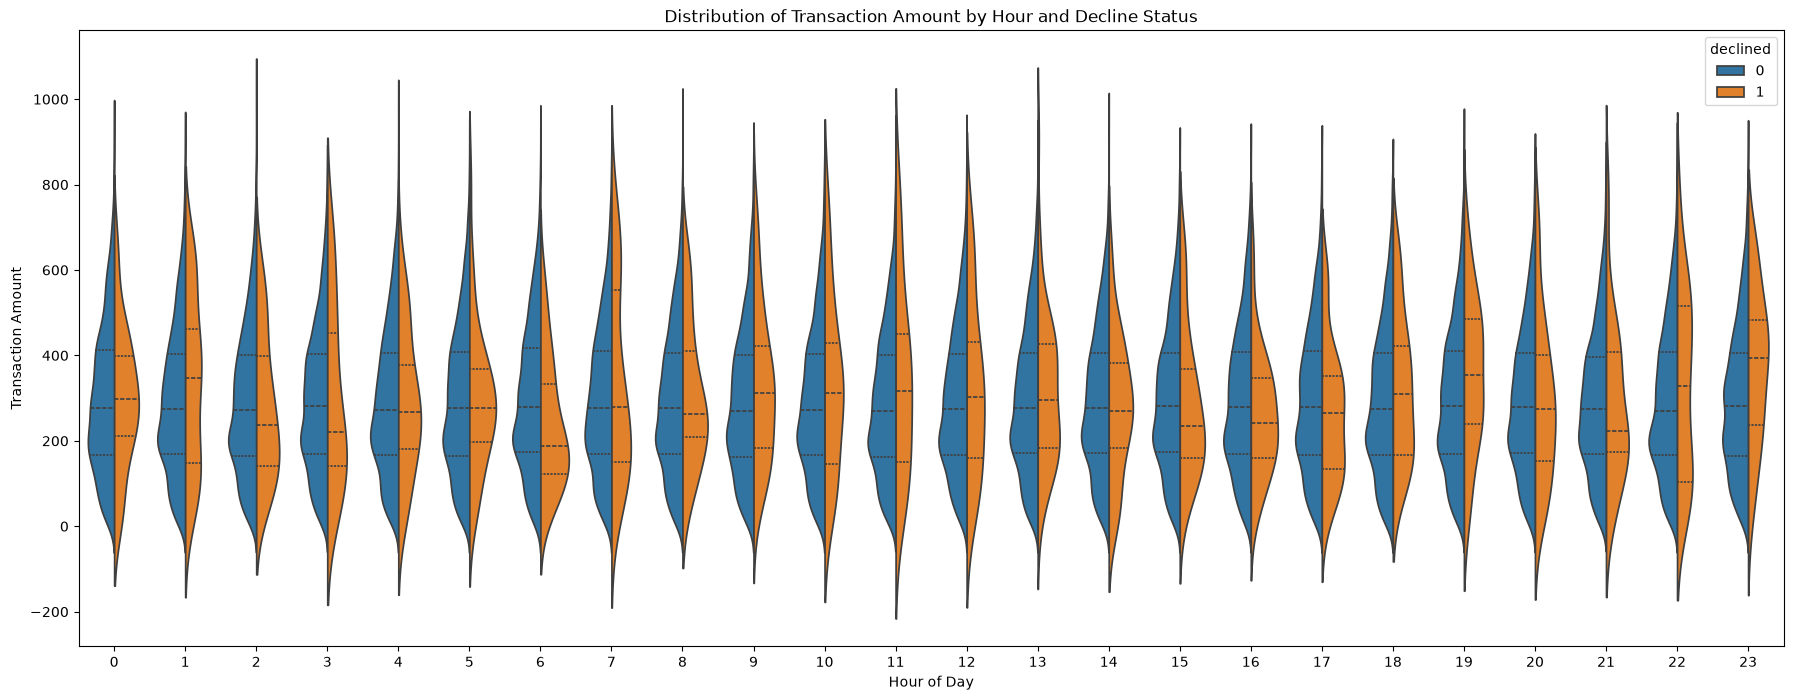

In [21]:
plt.figure(figsize=(22,8))

sns.violinplot(
    data=df_transactions,
    x="hour",
    y="amount",
    hue="declined",
    split=True,
    inner="quartile"
)

plt.title('Distribution of Transaction Amount by Hour and Decline Status')
plt.xlabel('Hour of Day')
plt.ylabel('Transaction Amount')
plt.show()

La solución propuesta por la IA es prácticamente idéntica a la solución que ya encontramos.

## 1.4 Actividad comercial según el día de la semana

El equipo comercial quiere conocer cómo se distribuye la actividad de ventas a lo largo de la semana.

El objetivo es determinar si determinados días concentran una mayor actividad y si esto podría tener implicaciones para la planificación comercial y operativa.

¿Qué días concentran una mayor actividad comercial y existen diferencias suficientemente relevantes como para adaptar la planificación?

In [22]:
df_transactions['day_of_week'] = df_transactions['timestamp'].dt.day_name()

order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

sales = (
    df_transactions[df_transactions["declined"] == 0]
    .groupby("day_of_week")
    .size()
    .reindex(order)
    .reset_index(name="total")
)

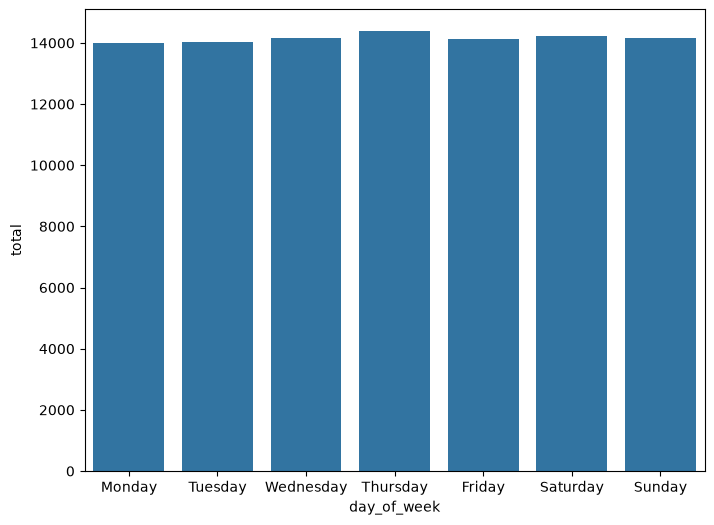

In [23]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=sales,
    x="day_of_week",
    y="total"
)

plt.show()

El número de transacciones se distribuye de forma bastante uniforme entre todos los días de la semana.

Aunque el jueves presenta un ligero incremento respecto al resto de días, la diferencia es reducida y no parece suficiente para afirmar que exista un patrón semanal claramente definido.

En consecuencia, no se aprecia una concentración significativa de la actividad comercial en un día concreto de la semana.

Solución propuesta por la IA:

C:\Users\Jordi\AppData\Local\Temp\ipykernel_7160\2889182885.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


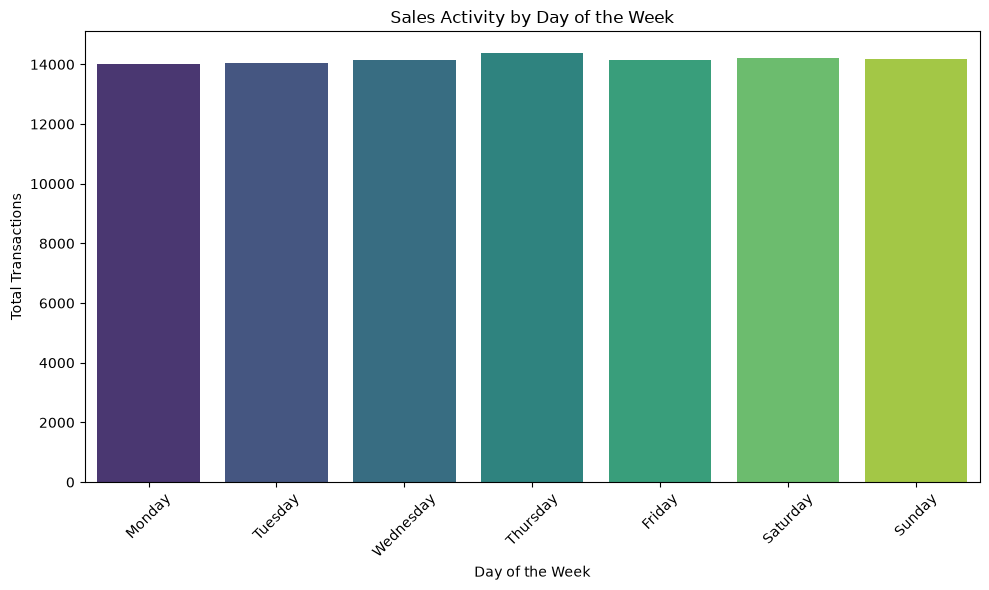

In [24]:
df_transactions['day_of_week'] = df_transactions['timestamp'].dt.day_name()

order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

sales_by_day = (
    df_transactions[df_transactions["declined"] == 0]
    .groupby("day_of_week")
    .size()
    .reindex(order)
    .reset_index(name="total_transactions")
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=sales_by_day,
    x="day_of_week",
    y="total_transactions",
    palette="viridis"
)
plt.title('Sales Activity by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La solución propuesta por la IA es bastante similar a la que ya habíamos encontrado, pero algo más pulcra.

################################################################

# 2. Concentración, estacionalidad y comportamiento comercial

A partir de los primeros resultados, la empresa quiere profundizar en determinados aspectos que pueden afectar a la estabilidad y crecimiento del negocio. El objetivo es detectar dependencias, patrones recurrentes y posibles oportunidades comerciales.

## 2.1 Dependencia geográfica de las compañías vendedoras

La dirección quiere conocer hasta qué punto la facturación depende de compañías vendedoras situadas en un número reducido de países.

Una concentración elevada podría incrementar la exposición del negocio a cambios económicos, regulatorios o competitivos en determinados mercados.

¿Existe una dependencia excesiva de un número reducido de países donde están ubicadas nuestras compañías vendedoras?

In [25]:
turnover_by_country = df_transactions.merge(
    df_companies,
    left_on='business_id',
    right_on='company_id',
    how="left"
)

turnover_by_country.head(3)

,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,...,time_slot,day_of_week,company_id,company_name,phone,email,country,website,merchant_category,merchant_price_position
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.20,1.44,...,Morning,Wednesday,b-2458,Eget Tincidunt Dui Institute,+18 210 327 5206,eget.laoreet@hotmail.org,Netherlands,https://www.eget-tincidunt-dui-institute.com,Toys,mid-market
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,"30, 11, 16, 81",2118,29.76,-95.38,...,Afternoon,Tuesday,b-2390,Neque Tellus Imperdiet Corp.,+12 445 145 3593,vestibulum.ante.ipsum@aol.edu,Ireland,https://www.neque-tellus-imperdiet-corp.com,Food,budget
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,175.00,0,72,2115,53.55,-113.50,...,Evening,Monday,b-2230,Fusce Corp.,+29 657 646 4324,risus@protonmail.edu,United States,https://www.fusce-corp.com,Home,mid-market


In [26]:
turnover_by_country = (
    turnover_by_country[turnover_by_country['declined'] == 0]
    .groupby('country')
    .agg(
        total_turnover=('amount','sum')
    )
    .sort_values(
        by='total_turnover',
        ascending=False
    )
)

turnover_by_country.head()

,total_turnover
country,
Sweden,4884077.83
Netherlands,4470873.59
United Kingdom,4065098.37
Italy,4061060.93
Germany,3984664.03


In [27]:
turnover_by_country['total_percent'] = (
    turnover_by_country['total_turnover'] /
    turnover_by_country['total_turnover'].sum()
    * 100
)

turnover_by_country.head()

,total_turnover,total_percent
country,,
Sweden,4884077.83,16.83
Netherlands,4470873.59,15.40
United Kingdom,4065098.37,14.01
Italy,4061060.93,13.99
Germany,3984664.03,13.73


In [28]:
turnover_by_country['total_percent'].cumsum().round(2)

country
Sweden            16.83
Netherlands       32.23
United Kingdom    46.24
Italy             60.23
Germany           73.96
France            78.80
United States     82.54
Belgium           85.77
Norway            88.52
Ireland           90.96
New Zealand       93.36
Australia         95.73
Canada            97.63
Spain             99.19
China            100.00
Name: total_percent, dtype: float64

In [29]:
turnover_by_country['pareto'] = (
    100 *
    turnover_by_country['total_percent'].cumsum() /
    turnover_by_country['total_percent'].sum()
)

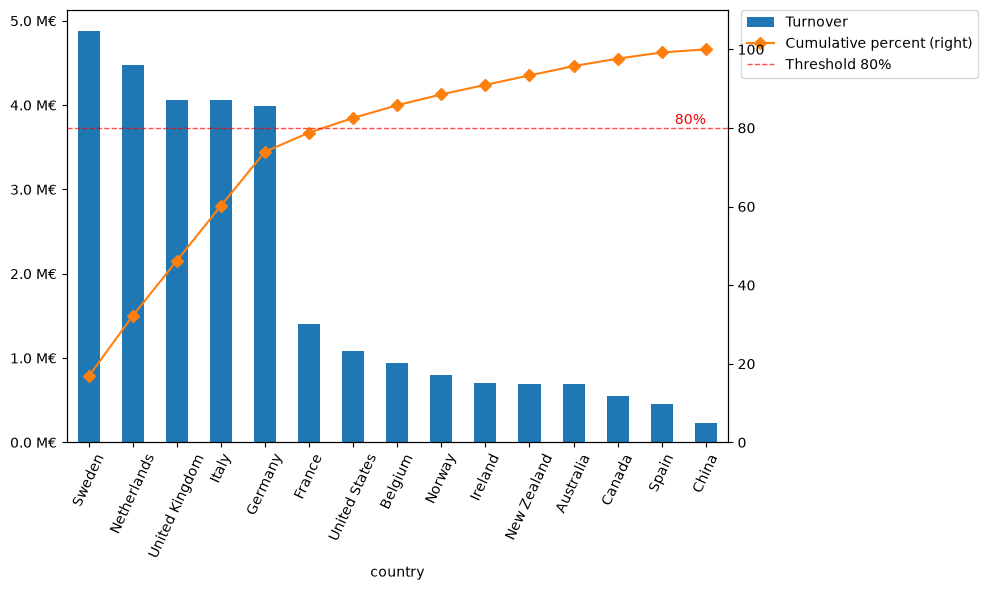

In [30]:
fig, axes = plt.subplots(figsize=(10, 6))

ax1 = turnover_by_country.plot(
    use_index=True,
    y="total_turnover",
    kind="bar",
    label="Turnover",
    ax=axes
)

ax1.yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"{x/1e6:.1f} M€"
    )
)

ax2 = turnover_by_country.plot(
    use_index=True,
    y="pareto",
    kind="line",
    marker="D",
    color="C1",
    label="Cumulative percent",
    secondary_y=True,
    ax=axes
)

ax2.set_ylim(0, 110)

ax2.axhline(
    y=80,
    color="red",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    label="Threshold 80%"
)

ax2.text(
    x=len(turnover_by_country) - 1,
    y=81,
    s="80%",
    color="red",
    ha="right",
    fontsize=10
)

axes.tick_params(axis="x", rotation=65)

# Combinar las leyendas de ambos ejes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

axes.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)

plt.tight_layout()
plt.show()

Al analizar la facturación por país y el porcentaje acumulado mediante un gráfico de Pareto, se observa que cinco países (Suecia, Países Bajos, Reino Unido, Italia y Alemania) concentran aproximadamente el 74% de la facturación total.

Esta concentración indica una elevada dependencia de un número reducido de mercados. Desde el punto de vista del negocio, esto supone un riesgo, ya que cualquier cambio económico, regulatorio o competitivo en alguno de estos países podría tener un impacto significativo sobre los ingresos globales.

Como estrategia, sería recomendable impulsar el crecimiento en aquellos países con menor peso en la facturación para diversificar el riesgo y reducir la dependencia de estos cinco mercados. No se trata de "diversificar compradores", sino de diversificar el origen de la facturación.

## 2.2 Estacionalidad de las ventas

El equipo comercial quiere determinar si existen patrones estacionales en la facturación.

Identificar meses con un comportamiento sistemáticamente superior o inferior permitiría mejorar la planificación comercial, anticipar periodos de menor demanda y diseñar campañas con mayor precisión.

¿Existe un patrón estacional en las ventas que permita anticipar periodos de mayor o menor demanda?

In [31]:
df_transactions['year'] = df_transactions['timestamp'].dt.year
df_transactions['month'] = df_transactions['timestamp'].dt.month

sales_table = pd.pivot_table(
    df_transactions[df_transactions["declined"] == 0],
    values="amount",
    index="month",
    columns="year",
    aggfunc="sum"
)

months = {
    1:"January",
    2:"February",
    3:"March",
    4:"April",
    5:"May",
    6:"June",
    7:"July",
    8:"August",
    9:"September",
    10:"October",
    11:"November",
    12:"December"
}

sales_table = sales_table.rename(index=months)

In [32]:
sales_table.style.format("{:.2f}") \
                .background_gradient(axis=None, cmap="coolwarm")

year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
month,,,,,,,,,,
January,221978.21,224451.27,222956.21,227411.90,222944.11,231702.95,243339.85,224709.53,228413.66,226393.73
February,245780.13,248112.42,252303.71,245092.09,259807.32,248318.04,257434.31,235427.85,251422.67,249898.07
March,253000.65,246634.37,237621.09,237099.83,276818.21,258872.56,250861.14,271978.12,241711.00,245792.02
April,245597.21,240833.04,251596.72,234246.30,242707.81,244251.90,259770.51,237165.49,241264.06,244769.15
May,248585.36,241306.84,240125.80,244448.97,242550.42,253699.74,239662.08,276262.60,261355.45,254122.62
June,232624.35,230577.43,240337.61,242769.22,241694.85,236410.96,234080.71,260082.37,232254.56,244370.81
July,241252.27,237081.73,240576.35,231261.73,233513.25,240255.64,251450.91,233349.01,238652.72,230031.53
August,233797.97,235600.88,230225.76,228759.89,237070.53,232658.86,237051.75,245198.95,237981.15,236671.63
September,227211.93,241530.84,230606.28,236768.38,232551.83,257964.96,245398.37,254316.72,234226.30,234226.89


<Axes: xlabel='year', ylabel='month'>

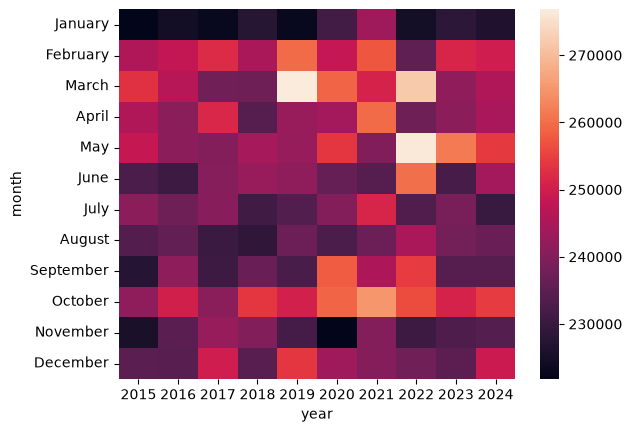

In [33]:
sns.heatmap(sales_table)

Analizando la evolución mensual de la facturación durante los diez años del estudio se aprecia un patrón relativamente consistente: enero presenta de forma recurrente uno de los niveles de facturación más bajos, mientras que febrero y octubre suelen concentrar algunos de los valores más elevados.

Esto sugiere la existencia de cierta estacionalidad, aunque sería recomendable analizar varios años adicionales o aplicar técnicas estadísticas específicas para confirmarla.

Desde el punto de vista del negocio, conocer estos patrones permite planificar campañas comerciales en los meses tradicionalmente más débiles y preparar mejor el stock, la logística y los recursos durante los periodos de mayor demanda.

# 2.3 Concentración y comportamiento de los productos

La empresa quiere identificar qué productos tienen un mayor impacto económico y comprender si su rendimiento es estable o presenta una elevada dispersión.

Este análisis permitirá evaluar si determinados productos tienen un peso desproporcionado en los ingresos y si existe riesgo de dependencia de un grupo reducido de productos.

¿Qué productos generan mayor valor para la empresa y qué características presenta su comportamiento de ventas?

In [34]:
df_transactions_products.head()

,transaction_id,product_id
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,16
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,26
2,00043A49-2949-494B-A5DD-A5BAE3BB19DD,97
3,00043A49-2949-494B-A5DD-A5BAE3BB19DD,87
4,00045D6B-ED2E-4F2F-8186-CEE074D875D0,30


In [35]:
# Enriquecemos df_transactions_products

df_transactions_products = df_transactions_products.merge(
    df_transactions[["id", "declined"]].rename(columns={"id":"transaction_id"}),
    on="transaction_id",
    how="left"
)

In [36]:
df_transactions_products = df_transactions_products.merge(
    df_products[["id", "price", "category"]].rename(columns={"id":"product_id"}),
    on="product_id",
    how="left"
)

In [37]:
df_transactions_products.head()

,transaction_id,product_id,declined,price,category
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,16,0,180.91,Home
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,26,0,53.01,Food
2,00043A49-2949-494B-A5DD-A5BAE3BB19DD,97,0,65.25,Beauty
3,00043A49-2949-494B-A5DD-A5BAE3BB19DD,87,0,96.26,Food
4,00045D6B-ED2E-4F2F-8186-CEE074D875D0,30,0,79.53,Electronics


In [38]:
turnover_by_product = (
    df_transactions_products[df_transactions_products["declined"] == 0]
    .groupby("product_id")
    .agg(
        total_turnover=("price", "sum"),
        ventas=("product_id", "count")
    )
    .nlargest(15, "total_turnover")
)

turnover_by_product

,total_turnover,ventas
product_id,,
39,499687.65,2541
64,497852.90,2545
67,494748.50,2525
15,486696.45,2505
93,484389.00,2515
62,476317.74,2521
86,473971.05,2505
63,472204.32,2504
16,467290.53,2583


In [39]:
turnover_by_product = (
    turnover_by_product
    .reset_index()
    .merge(
        df_products[["id", "product_name", "category"]].rename(columns={"id":"product_id"}),
        left_on="product_id",
        right_on="product_id",
        how="left"
    )
)

turnover_by_product

,product_id,total_turnover,ventas,product_name,category
0,39,499687.65,2541,warden,Toys
1,64,497852.90,2545,Direwolf,Fashion
2,67,494748.50,2525,Winterfell,Home
3,15,486696.45,2505,Stannis warden,Home
4,93,484389.00,2515,Littlefinger Tarly Stark,Food
5,62,476317.74,2521,the duel,Fashion
6,86,473971.05,2505,Stark kingsblood,Fashion
7,63,472204.32,2504,Jade tatooine dooku,Travel
8,16,467290.53,2583,the duel warden,Home
9,12,459629.60,2531,duel Direwolf,Gaming


<Axes: xlabel='total_turnover', ylabel='product_name'>

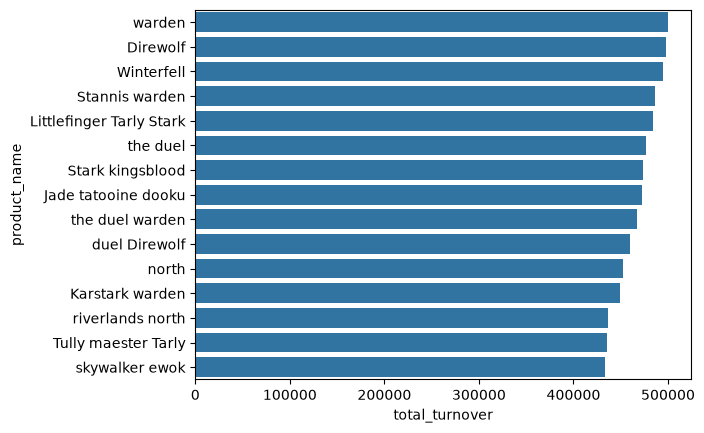

In [40]:
sns.barplot(
    data=turnover_by_product,
    x="total_turnover",
    y="product_name"
)

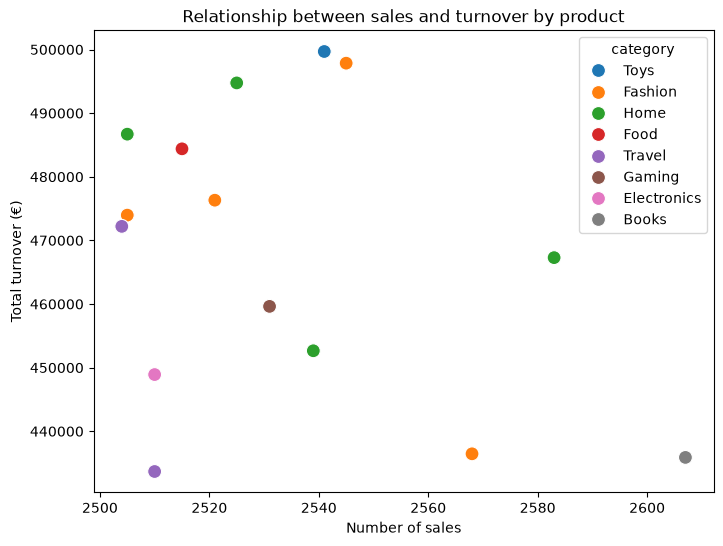

In [41]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=turnover_by_product,
    x="ventas",
    y="total_turnover",
    hue="category",
    s=100
)

plt.title("Relationship between sales and turnover by product")
plt.xlabel("Number of sales")
plt.ylabel("Total turnover (€)")

plt.show()

Con la información disponible no es posible medir la variabilidad real de los ingresos por producto. El dataset únicamente indica qué productos participaron en cada transacción y el precio de catálogo de cada uno, pero no cuánto dinero aportó cada producto al importe final de la compra.

Por ello únicamente puede analizarse la relación entre el número de ventas en las que aparece un producto y la suma de sus precios de catálogo.

Tampoco se observa una relación clara entre la categoría del producto y el volumen de ingresos o el número de ventas.

## 2.4 Reactivación de clientes

El equipo de Ventas quiere identificar clientes que han dejado de comprar recientemente o que llevan un periodo prolongado sin realizar ninguna compra.

El objetivo es detectar posibles señales de abandono y establecer segmentos de clientes sobre los que pueda ser interesante realizar acciones de reactivación.

¿Qué clientes presentan señales de inactividad y existe una oportunidad de recuperarlos mediante acciones comerciales?

In [42]:
last_purchase = (
    df_transactions[df_transactions["declined"] == 0]
    .groupby("user_id")["timestamp"]
    .max()
)

In [43]:
days_without_buying = (
    pd.DataFrame({
        "days_without_buying":
        (df_transactions["timestamp"].max() - last_purchase).dt.days
    })
    .reset_index()
)

In [44]:
df_transactions["user_id"].nunique()

5000

In [45]:
days_without_buying[days_without_buying['days_without_buying'] >= 100].nunique()

user_id                2934
days_without_buying     647
dtype: int64

(0.0, 250.0)

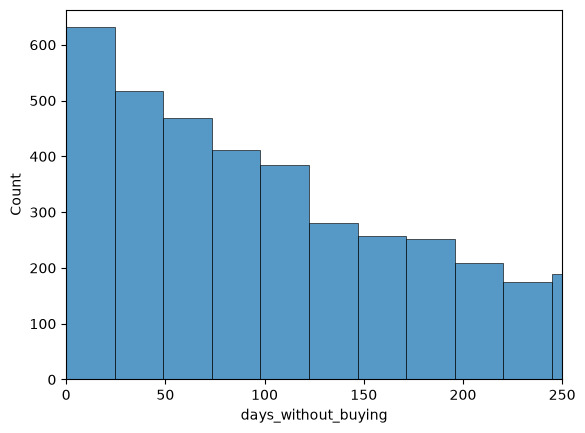

In [46]:
sns.histplot(
    data=days_without_buying,
    x="days_without_buying"
)

plt.xlim(0,250)

(250.0, 1836.0)

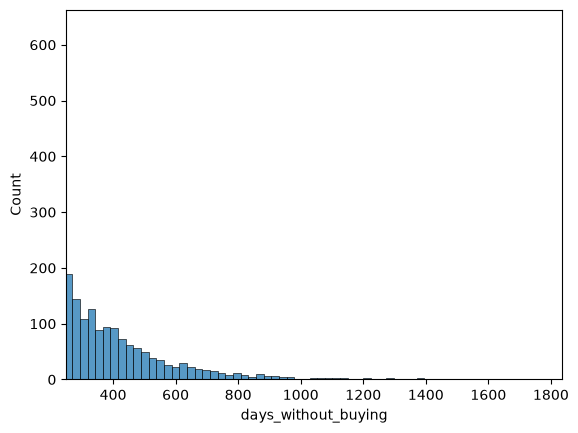

In [47]:
# Histograma de usuarios que llevan más de 250 días sin comprar

sns.histplot(
    data=days_without_buying,
    x="days_without_buying"
)

plt.xlim(250, days_without_buying["days_without_buying"].max())

<Axes: xlabel='days_without_buying', ylabel='Count'>

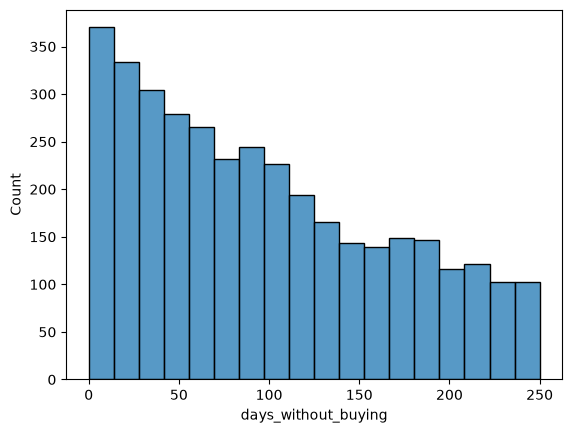

In [48]:
sns.histplot(
    data=days_without_buying[days_without_buying['days_without_buying'] <= 250],
    x='days_without_buying'
)

La mayoría de los usuarios han realizado alguna compra durante los últimos meses, aunque existe un grupo de clientes cuya última compra fue hace más de 250 días.

Estos usuarios representan una oportunidad para desarrollar campañas de recuperación (win-back), ya que probablemente hayan abandonado la plataforma o reducido significativamente su actividad.

También podría definirse un segundo segmento formado por usuarios cuya última compra se realizó entre 100 y 250 días atrás. Estos clientes todavía mantienen una relación relativamente reciente con la empresa y podrían responder mejor a acciones comerciales menos agresivas, como descuentos personalizados, recomendaciones o campañas de fidelización.

Priorizar este tipo de acciones puede resultar más rentable que centrar todos los esfuerzos únicamente en captar nuevos clientes.

## 2.5 Patrones horarios

La dirección comercial quiere conocer si el comportamiento de compra cambia según la franja horaria y si estos patrones se mantienen estables a lo largo de los años.

El objetivo es determinar si existen momentos concretos en los que la actividad comercial sea significativamente mayor o menor.

¿Cómo se distribuye la actividad comercial a lo largo del día y ha cambiado este comportamiento con el tiempo?

In [49]:
time_slot_year_table = pd.crosstab(
    df_transactions["time_slot"],
    df_transactions["year"],
    normalize="columns"
)

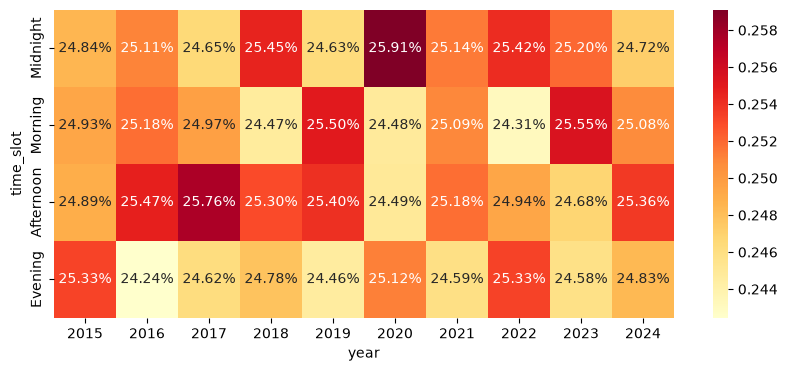

In [50]:
plt.figure(figsize=(10,4))

sns.heatmap(
    time_slot_year_table,
    annot=True,
    cmap="YlOrRd", #"coolwarm"
    fmt=".2%"
)

plt.show()

In [51]:
# Valor máximo y mínimo y diferencia entre ambos

max_value = time_slot_year_table.max().max()
min_value = time_slot_year_table.min().min()

print((max_value*100))
print((min_value*100))
print((max_value - min_value)*100)

25.90904587337759
24.243961842906433
1.665084030471156


In [52]:
# Cuándo se producen el valor máximo y el mínimo?

max_loc = time_slot_year_table.stack().idxmax()
min_loc = time_slot_year_table.stack().idxmin()

print(max_loc)
print(min_loc)

('Midnight', np.int32(2020))
('Evening', np.int32(2016))


La distribución de ventas por franjas horarias permanece muy estable durante los diez años analizados.

La mayor proporción de ventas se registra durante la madrugada en 2020, mientras que la menor corresponde a la noche en 2016. Sin embargo, la diferencia entre ambos extremos es de aproximadamente 1,7 puntos porcentuales, por lo que el comportamiento horario de los clientes apenas varía entre años.

Desde el punto de vista del negocio, esto indica que no sería necesario diseñar estrategias comerciales diferentes según el año para determinadas franjas horarias. Las campañas promocionales, la planificación de recursos o la capacidad de la plataforma pueden mantenerse de forma relativamente uniforme durante todo el día, priorizando únicamente pequeñas optimizaciones operativas.

################################################################

# N2

# 3. Productos y captación de clientes

El equipo de Ventas quiere ir más allá del volumen de facturación y entender qué papel desempeñan los productos en el crecimiento de la base de clientes.

No todos los productos tienen necesariamente la misma función dentro del negocio: algunos pueden atraer nuevos clientes, mientras que otros pueden estar principalmente asociados a clientes recurrentes.

## 3.1 Rendimiento y capacidad de captación de los productos

La empresa quiere analizar conjuntamente el rendimiento económico de los productos y su capacidad para atraer nuevos usuarios.

El objetivo es identificar diferentes perfiles de producto, por ejemplo:


*   productos que atraen nuevos clientes;
*   productos asociados principalmente a clientes recurrentes;
*   productos con potencial de crecimiento;
*   productos con bajo rendimiento y baja capacidad de captación.

¿Los productos que generan más ingresos también contribuyen al crecimiento de la base de clientes o el negocio depende principalmente de usuarios recurrentes?

In [53]:
df_first_transactions = df_transactions_products.merge(
    df_transactions[
        [
            "id",
            "timestamp",
            "amount",
            "user_id",
            "discount_amount",
            "tax_amount",
            "shipping_amount"
        ]
    ].rename(columns={"id": "transaction_id"}),
    on="transaction_id",
    how="left"
)

df_first_transactions = df_first_transactions.merge(
    df_products[
        [
            "id",
            "product_name"
        ]
    ].rename(columns={"id": "product_id"}),
    on="product_id",
    how="left"
)

# eliminamos transacciones rechazadas
df_first_transactions = (
    df_first_transactions[
        df_first_transactions["declined"] == 0
    ]
)

df_first_transactions.head()

,transaction_id,product_id,declined,price,category,timestamp,amount,user_id,discount_amount,tax_amount,shipping_amount,product_name
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,16,0,180.91,Home,2024-08-28 07:16:46,433.51,4713,34.17,72.25,0.00,the duel warden
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,26,0,53.01,Food,2024-08-28 07:16:46,433.51,4713,34.17,72.25,0.00,Stark Karstark
2,00043A49-2949-494B-A5DD-A5BAE3BB19DD,97,0,65.25,Beauty,2024-08-28 07:16:46,433.51,4713,34.17,72.25,0.00,jinn Winterfell
3,00043A49-2949-494B-A5DD-A5BAE3BB19DD,87,0,96.26,Food,2024-08-28 07:16:46,433.51,4713,34.17,72.25,0.00,sith Jade
4,00045D6B-ED2E-4F2F-8186-CEE074D875D0,30,0,79.53,Electronics,2020-07-14 15:37:45,332.38,2118,16.10,22.47,0.00,Karstark warden


In [54]:
first_transactions = (
    df_first_transactions
    .sort_values("timestamp")
    .drop_duplicates("user_id")
)

In [55]:
df_first_transactions["is_new_user"] = (
    df_first_transactions["transaction_id"]
    .isin(first_transactions["transaction_id"])
)

df_first_transactions.head()

,transaction_id,product_id,declined,price,category,timestamp,amount,user_id,discount_amount,tax_amount,shipping_amount,product_name,is_new_user
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,16,0,180.91,Home,2024-08-28 07:16:46,433.51,4713,34.17,72.25,0.00,the duel warden,False
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,26,0,53.01,Food,2024-08-28 07:16:46,433.51,4713,34.17,72.25,0.00,Stark Karstark,False
2,00043A49-2949-494B-A5DD-A5BAE3BB19DD,97,0,65.25,Beauty,2024-08-28 07:16:46,433.51,4713,34.17,72.25,0.00,jinn Winterfell,False
3,00043A49-2949-494B-A5DD-A5BAE3BB19DD,87,0,96.26,Food,2024-08-28 07:16:46,433.51,4713,34.17,72.25,0.00,sith Jade,False
4,00045D6B-ED2E-4F2F-8186-CEE074D875D0,30,0,79.53,Electronics,2020-07-14 15:37:45,332.38,2118,16.10,22.47,0.00,Karstark warden,False


In [56]:
product_metrics = (
    df_first_transactions
    .groupby(
        [
            "product_id",
            "product_name"
        ]
    )
    .agg(
        total_revenue=("price", "sum"),
        variability=("amount", "std"),
        buyers=("user_id", "nunique")
    )
)

product_metrics

,,total_revenue,variability,buyers
product_id,product_name,,,
1,Direwolf Stannis,394719.50,151.83,1890
2,Tarly Stark,23580.48,148.59,1949
3,duel tourney Lannister,429022.91,154.30,1921
4,warden south duel,184254.07,148.07,1945
5,skywalker ewok,433186.60,151.09,1932
...,...,...,...,...
96,dooku solo,52007.12,153.00,1912
97,jinn Winterfell,164038.50,149.91,1894
98,Direwolf Littlefinger,97588.18,156.87,1934


In [57]:
# Cuántos nuevos usuarios compran cada producto en su primera compra?

new_users = (
    df_first_transactions[
        df_first_transactions["is_new_user"]
    ]
    .groupby("product_id")
    .agg(
        new_users=("user_id", "nunique")
    )
)

new_users

,new_users
product_id,
1,110
2,126
3,126
4,121
5,152
...,...
96,99
97,121
98,120


In [58]:
product_metrics = (
    product_metrics
    .merge(
        new_users,
        on="product_id",
        how="left"
    )
)

In [59]:
product_metrics["new_users"] = (
    product_metrics["new_users"]
    .fillna(0)
    .astype(int)
)

In [60]:
product_metrics["percentage_new"] = (
    product_metrics["new_users"]
    /
    product_metrics["buyers"]
    *100
)

product_metrics

,total_revenue,variability,buyers,new_users,percentage_new
product_id,,,,,
1,394719.50,151.83,1890,110,5.82
2,23580.48,148.59,1949,126,6.46
3,429022.91,154.30,1921,126,6.56
4,184254.07,148.07,1945,121,6.22
5,433186.60,151.09,1932,152,7.87
...,...,...,...,...,...
96,52007.12,153.00,1912,99,5.18
97,164038.50,149.91,1894,121,6.39
98,97588.18,156.87,1934,120,6.20


In [61]:
product_metrics.describe()

,total_revenue,variability,buyers,new_users,percentage_new
count,100.00,100.00,100.00,100.00,100.00
mean,256595.97,151.17,1933.59,125.21,6.47
std,151136.63,3.52,32.03,11.16,0.55
min,5456.88,144.47,1853.00,99.00,5.17
25%,133899.28,148.89,1913.00,120.00,6.19
50%,248887.30,150.46,1931.50,126.00,6.50
75%,396712.07,152.37,1955.25,131.00,6.80
max,499687.65,163.84,2027.00,153.00,7.87


In [62]:
revenue_mean = product_metrics["total_revenue"].mean()
print(revenue_mean)

percentage_new_median = product_metrics["percentage_new"].median()
print(percentage_new_median)

256595.9694
6.503657884585451


In [63]:
def classify_product(row):

    if (
        row["total_revenue"] >= revenue_mean
        and
        row["percentage_new"] >= percentage_new_median
    ):
        return "Customer acquisition product"

    elif (
        row["total_revenue"] >= revenue_mean
        and
        row["percentage_new"] < percentage_new_median
    ):
        return "Repeat-purchase product"

    elif (
        row["total_revenue"] < revenue_mean
        and
        row["percentage_new"] >= percentage_new_median
    ):
        return "Emerging product"

    else:
        return "Stagnant product"

In [64]:
product_metrics["typology"] = (
    product_metrics.apply(
        classify_product,
        axis=1
    )
)

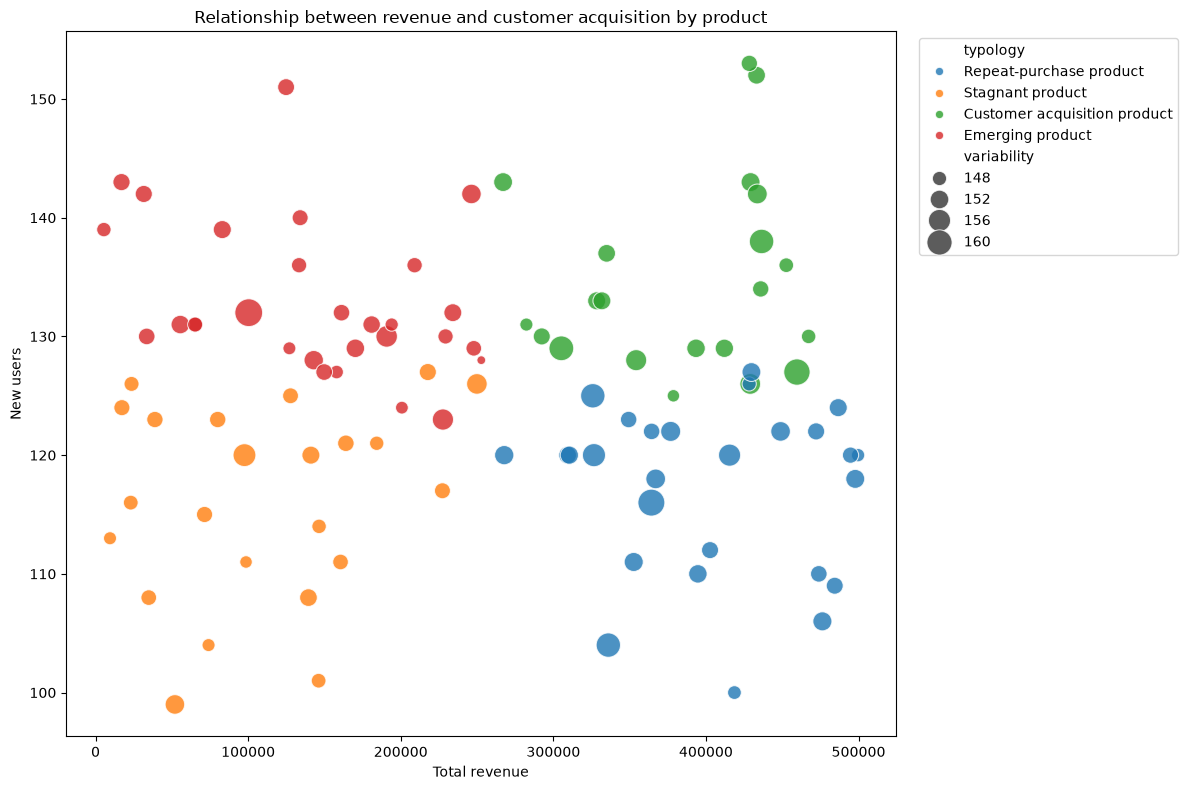

In [65]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=product_metrics,
    x="total_revenue",
    y="new_users",
    hue="typology",
    size="variability",
    sizes=(40,400),
    alpha=0.8
)

plt.title("Relationship between revenue and customer acquisition by product")

plt.xlabel("Total revenue")

plt.ylabel("New users")

plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()

plt.show()

Interpretación del negocio

Con esta metodología podemos clasificar los productos según su comportamiento comercial:

Captadores: generan elevados ingresos y además atraen una gran proporción de nuevos clientes. Son productos estratégicos tanto para el crecimiento como para la facturación.

Recurrentes: generan muchos ingresos, pero la mayoría proceden de clientes existentes. Son fundamentales para la fidelización, aunque aportan poco crecimiento.

Emergentes: todavía generan poca facturación, pero presentan una buena capacidad para captar nuevos clientes. Podrían convertirse en productos estratégicos mediante acciones comerciales o de marketing.

Estancados: presentan baja facturación y escasa captación de nuevos usuarios. Conviene revisar su posicionamiento, promocionarlos o valorar incluso su retirada del catálogo.

# el negocio depende mucho de una base estable de usuarios recurrentes. esto es beneficioso a corto plazo, pero supone un riesgo a largo plazo debido a que no entran muchos nuevos usuarios

El dataset no proporciona el valor individual aportado por cada producto dentro de una transacción con múltiples productos.

Por este motivo no es posible calcular exactamente la variabilidad de los ingresos por producto.

Como aproximación, hemos utilizado la variabilidad del importe total de las transacciones donde aparece cada producto, interpretando esta métrica como una medida de la diversidad del contexto de compra y no como la variabilidad real de los ingresos del producto.

Los productos de tipo recurrente y de tipo captador presentan mayor "variabilidad"

################################################################

# 4. Expansión internacional

La empresa opera a través de compañías vendedoras ubicadas en diferentes países y cuenta con clientes residentes en distintos mercados.

La dirección quiere determinar si el negocio tiene principalmente un comportamiento local, donde clientes y compañías pertenecen al mismo país, o si existe una actividad internacional suficientemente relevante como para plantear oportunidades de expansión.

## 4.1 Comportamiento local vs. internacional

Analiza qué proporción de la actividad comercial y de la facturación procede de operaciones locales frente a operaciones internacionales.

¿El negocio depende principalmente de operaciones locales o existe una actividad internacional relevante?

In [66]:
df_sales_location = df_transactions[['id', 'business_id', 'amount', 'declined', 'user_id', 'shipping_amount', 'is_international', 'distance_km']].rename(columns={"id": "transaction_id"}).copy()

df_sales_location = df_sales_location[df_sales_location['declined'] == 0]

df_sales_location.head()

,transaction_id,business_id,amount,declined,user_id,shipping_amount,is_international,distance_km
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,433.51,0,4713,0.00,0,59.95
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,b-2390,332.38,0,2118,0.00,1,1157.10
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,b-2230,175.00,0,2115,0.00,0,540.32
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,b-2266,158.55,0,3025,8.99,0,28.52
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,b-2598,317.97,0,215,0.00,0,539.82


In [67]:
df_sales_location = df_sales_location.merge(
    df_companies[
        [
            "company_id",
            "company_name",
            "country"
        ]
    ].rename(columns={"company_id": "business_id", "country": "company_country"}),
    on="business_id",
    how="left"
)

df_sales_location = df_sales_location.merge(
    df_users[
        [
            "id",
            "name",
            "country"
        ]
    ].rename(columns={"id": "user_id", "name": "user_name", "country": "user_country"}),
    on="user_id",
    how="left"
)

df_sales_location

,transaction_id,business_id,amount,declined,user_id,shipping_amount,is_international,distance_km,company_name,company_country,user_name,user_country
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,433.51,0,4713,0.00,0,59.95,Eget Tincidunt Dui Institute,Netherlands,Gxnmjn,France
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,b-2390,332.38,0,2118,0.00,1,1157.10,Neque Tellus Imperdiet Corp.,Ireland,Wolake,United States
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,b-2230,175.00,0,2115,0.00,0,540.32,Fusce Corp.,United States,Umhwoi,Canada
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,b-2266,158.55,0,3025,8.99,0,28.52,Mus Aenean Eget Foundation,Sweden,Qpfyfa,Netherlands
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,b-2598,317.97,0,215,0.00,0,539.82,Aliquam Iaculis Lacus Corp.,Belgium,Keegan,Canada
...,...,...,...,...,...,...,...,...,...,...,...,...
99106,FFF9E3CE-234E-408C-A8EF-F9CAD577224A,b-2234,278.42,0,429,6.99,0,0.25,Convallis In Incorporated,Germany,Yshimq,Germany
99107,FFFB270D-F53A-4D5D-9666-E5307C53CC84,b-2522,403.66,0,3074,0.00,0,42.71,Viverra Donec Foundation,United Kingdom,Ggzjpa,Portugal
99108,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,b-2302,295.43,0,1008,4.99,0,0.53,Nunc Interdum Incorporated,Germany,Securp,Sweden
99109,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,b-2250,183.02,0,680,3.99,0,67.56,Amet Nulla Donec Corporation,Italy,Dfrled,Netherlands


In [68]:
df_sales_location["local_purchases"] = (
    df_sales_location["company_country"] == df_sales_location["user_country"]
)

In [69]:
local_sales_percent = len(df_sales_location[df_sales_location["local_purchases"] == True]) / len(df_sales_location) * 100
international_sales_percent = len(df_sales_location[df_sales_location["local_purchases"] == False]) / len(df_sales_location) * 100

print(f'Local sales percent: {local_sales_percent:.2f}')
print(f'International sales percent: {international_sales_percent:.2f}')

Local sales percent: 11.87
International sales percent: 88.13


In [70]:
local_revenue_percent = (df_sales_location["amount"][df_sales_location["local_purchases"] == True].sum() / df_sales_location["amount"].sum() * 100)
international_revenue_percent = (df_sales_location["amount"][df_sales_location["local_purchases"] == False].sum() / df_sales_location["amount"].sum() * 100)

print(f'Local revenue percent: {local_revenue_percent:.2f}')
print(f'International revenue percent: {international_revenue_percent:.2f}')

Local revenue percent: 11.89
International revenue percent: 88.11


La gran mayoría de ventas son ventas internacionales, y la gran mayoría de la facturación se produce por ventas internacionales.

## 4.2 Demanda internacional por país

Para cada país de residencia de los clientes, la dirección quiere conocer:

*   cuánto compran;
*   qué proporción de sus compras se realiza dentro de su propio país;
*   qué proporción se realiza en mercados extranjeros.

El objetivo es identificar mercados donde exista una demanda significativa pero una presencia local limitada.

¿En qué países existe una demanda significativa que actualmente se está cubriendo principalmente mediante compañías extranjeras?

In [71]:
# Función para generar un resumen de compras locales, internaciones, facturación en base a una columna de país

def country_summary(df, country_column):

    summary = (
        df
        .groupby(country_column)
        .agg(
            purchases=("transaction_id","count"),
            local_purchases=("local_purchases","sum"),
            amount_sum=("amount","sum")
        )
    )

    summary["local_percent"] = (
        summary["local_purchases"]/summary["purchases"]*100
    )

    summary["international_purchases"] = (
            summary["purchases"] - summary["local_purchases"]
        )

    summary["international_percent"] = (
        100-summary["local_percent"]
    )

    return summary

In [72]:
# Resumen de compras y facturación por país del usuario

user_summary = country_summary(
    df_sales_location,
    "user_country"
)

In [73]:
user_summary = user_summary.sort_values(
    by="purchases",
    ascending=False
)

user_summary

,purchases,local_purchases,amount_sum,local_percent,international_purchases,international_percent
user_country,,,,,,
United States,11343,2104,3049853.50,18.55,9239,81.45
Canada,9845,957,2650339.29,9.72,8888,90.28
United Kingdom,9577,1656,2819917.93,17.29,7921,82.71
Netherlands,8889,1721,2651840.50,19.36,7168,80.64
Spain,8881,154,2668434.76,1.73,8727,98.27
Portugal,8704,0,2615801.06,0.00,8704,100.00
Germany,8653,1467,2550878.07,16.95,7186,83.05
Italy,8510,1456,2585429.93,17.11,7054,82.89
France,8437,530,2467840.16,6.28,7907,93.72


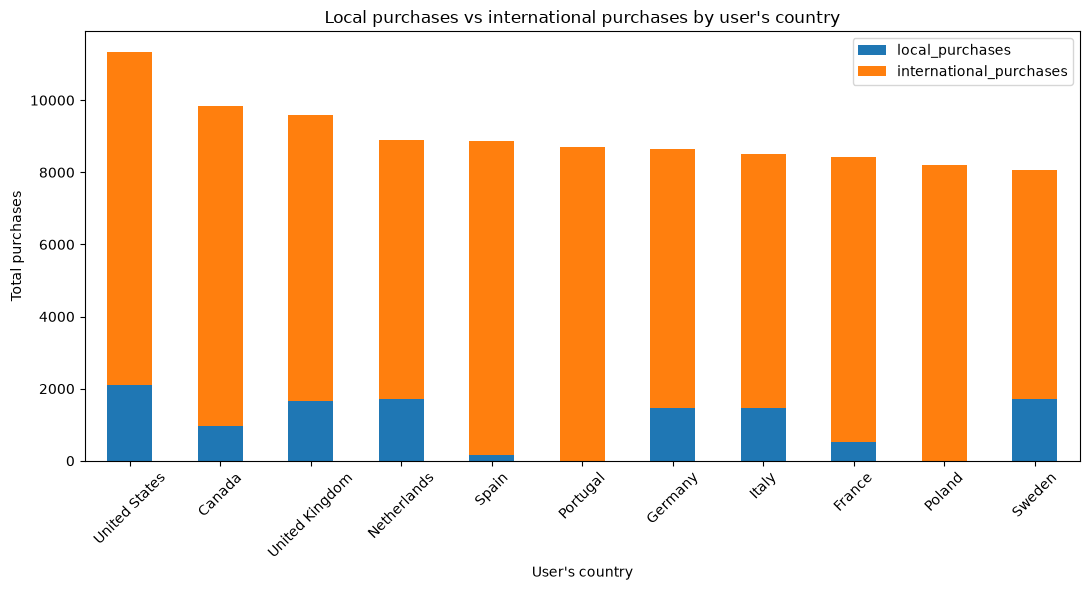

In [74]:
user_summary[
    ["local_purchases", "international_purchases"]
].plot(
    kind="bar",
    stacked=True,
    figsize=(11,6)
)

plt.ylabel("Total purchases")
plt.xlabel("User's country")
plt.title("Local purchases vs international purchases by user's country")
plt.xticks(rotation=45)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

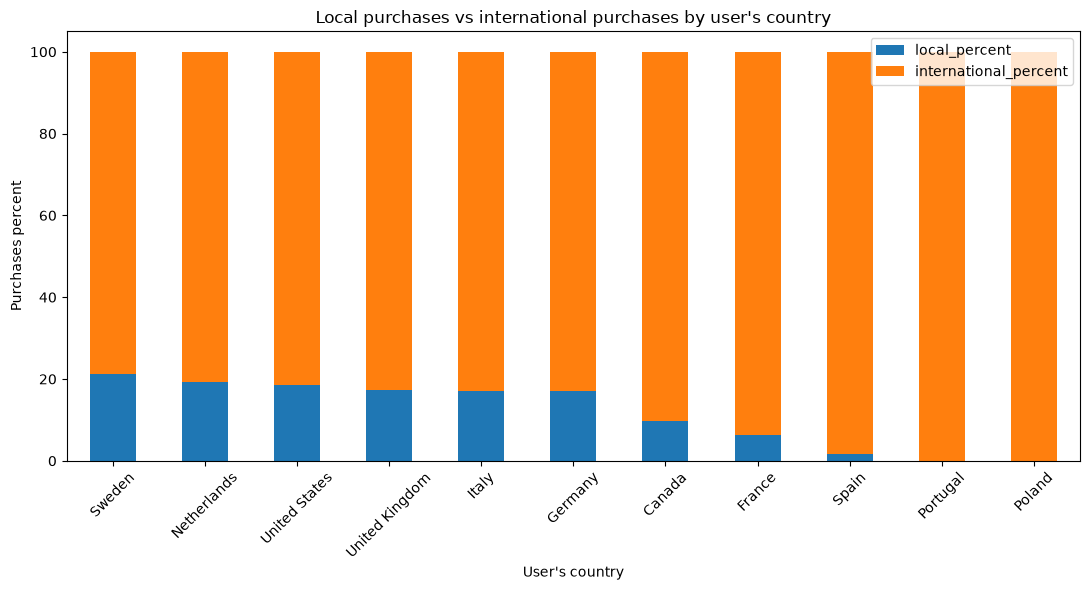

In [75]:
user_summary = user_summary.sort_values(
    by="local_percent",
    ascending=False
)

user_summary[
    ["local_percent", "international_percent"]
].plot(
    kind="bar",
    stacked=True,
    figsize=(11,6)
)

plt.ylabel("Purchases percent")
plt.xlabel("User's country")
plt.title("Local purchases vs international purchases by user's country")
plt.xticks(rotation=45)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 4.3 Dependencia y oportunidad de expansión

También se quiere analizar la procedencia de los ingresos de las compañías según el país de residencia de sus clientes.

El objetivo es detectar:

*   mercados con una fuerte demanda internacional;
*   países donde las compañías locales tienen una participación reducida;
*   posibles oportunidades para aumentar la presencia local;
*   dependencias excesivas de determinados mercados.

¿En qué mercados podría tener sentido aumentar la presencia local para capturar una demanda que actualmente se atiende desde otros países?

In [76]:
# Resumen de compras y facturación por país de la compañía

company_summary = country_summary(
    df_sales_location,
    "company_country"
)

company_summary

,purchases,local_purchases,amount_sum,local_percent,international_purchases,international_percent
company_country,,,,,,
Australia,2523,0,687532.20,0.00,2523,100.00
Belgium,3484,0,937789.26,0.00,3484,100.00
Canada,2082,957,552067.53,45.97,1125,54.03
China,903,0,235421.76,0.00,903,100.00
France,4669,530,1406668.15,11.35,4139,88.65
Germany,13182,1467,3984664.03,11.13,11715,88.87
Ireland,2627,0,707379.30,0.00,2627,100.00
Italy,13580,1456,4061060.93,10.72,12124,89.28
Netherlands,14945,1721,4470873.59,11.52,13224,88.48


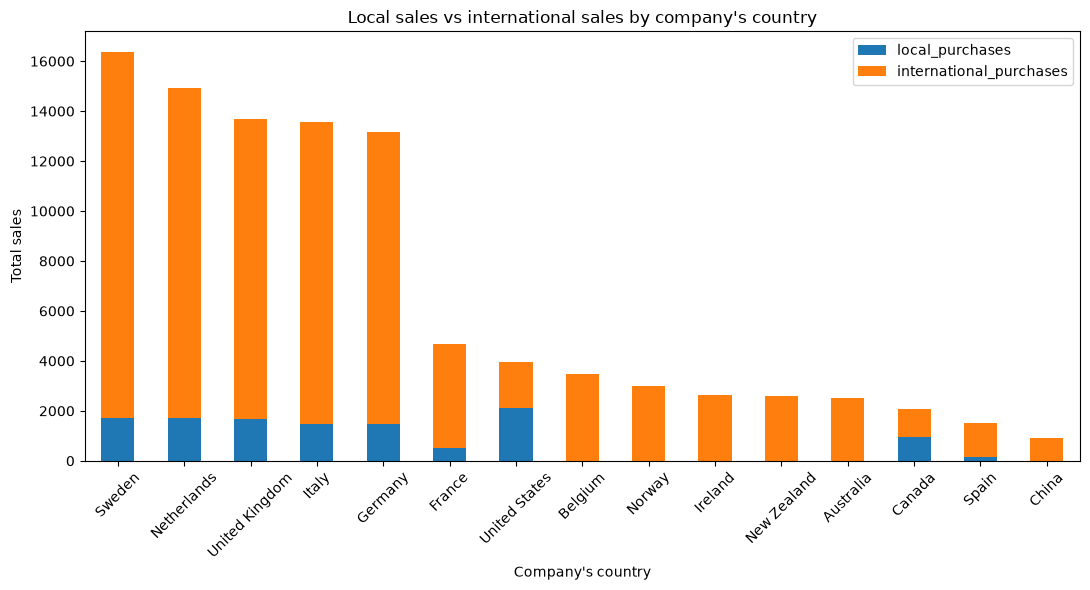

In [77]:
company_summary = company_summary.sort_values(
    by="purchases",
    ascending=False
)

company_summary[
    ["local_purchases", "international_purchases"]
].plot(
    kind="bar",
    stacked=True,
    figsize=(11,6)
)

plt.ylabel("Total sales")
plt.xlabel("Company's country")
plt.title("Local sales vs international sales by company's country")
plt.xticks(rotation=45)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

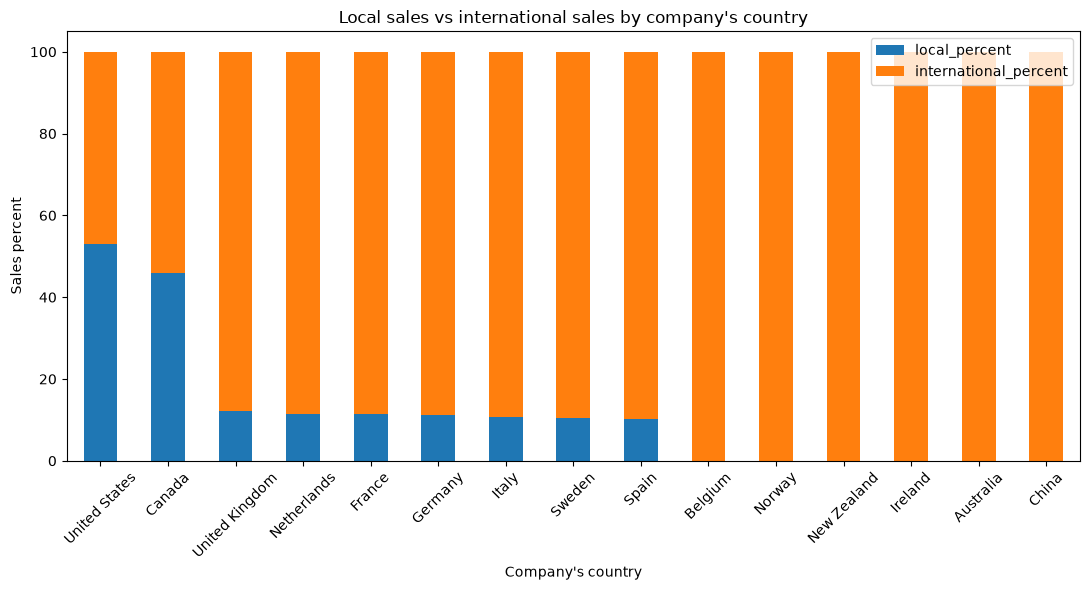

In [78]:
company_summary = company_summary.sort_values(
    by="local_percent",
    ascending=False
)

company_summary[
    ["local_percent", "international_percent"]
].plot(
    kind="bar",
    stacked=True,
    figsize=(11,6)
)

plt.ylabel("Sales percent")
plt.xlabel("Company's country")
plt.title("Local sales vs international sales by company's country")
plt.xticks(rotation=45)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [79]:
cross_country_revenue_flows = pd.pivot_table(
    df_sales_location,
    index="user_country",
    columns="company_country",
    values="amount",
    aggfunc="sum",
    fill_value=0
)

cross_country_revenue_flows

company_country,Australia,Belgium,Canada,China,France,Germany,Ireland,Italy,Netherlands,New Zealand,Norway,Spain,Sweden,United Kingdom,United States
user_country,,,,,,,,,,,,,,,
Canada,308671.74,441008.16,254806.44,106346.47,0.00,0.00,329718.77,0.00,0.00,324591.49,375501.18,0.00,0.00,0.00,509695.04
France,0.00,0.00,0.00,0.00,153765.65,406030.70,0.00,424787.49,471499.65,0.00,0.00,49283.17,524024.06,438449.44,0.00
Germany,0.00,0.00,0.00,0.00,142890.73,444114.60,0.00,449014.41,496187.38,0.00,0.00,54753.76,523210.62,440706.57,0.00
Italy,0.00,0.00,0.00,0.00,149098.57,442048.37,0.00,440575.65,496839.68,0.00,0.00,59801.50,553971.12,443095.04,0.00
Netherlands,0.00,0.00,0.00,0.00,163286.99,422754.29,0.00,465397.74,518415.63,0.00,0.00,49586.82,557825.99,474573.04,0.00
Poland,0.00,0.00,0.00,0.00,153539.45,447321.05,0.00,423701.80,451028.22,0.00,0.00,46274.56,520137.55,449049.73,0.00
Portugal,0.00,0.00,0.00,0.00,158833.33,463578.98,0.00,447260.48,522496.23,0.00,0.00,43776.18,532540.40,447315.46,0.00
Spain,0.00,0.00,0.00,0.00,166409.89,448032.94,0.00,460326.44,517591.90,0.00,0.00,48484.18,569380.90,458208.51,0.00
Sweden,0.00,0.00,0.00,0.00,149503.94,416950.36,0.00,434481.77,469730.72,0.00,0.00,51207.46,526911.33,425036.71,0.00


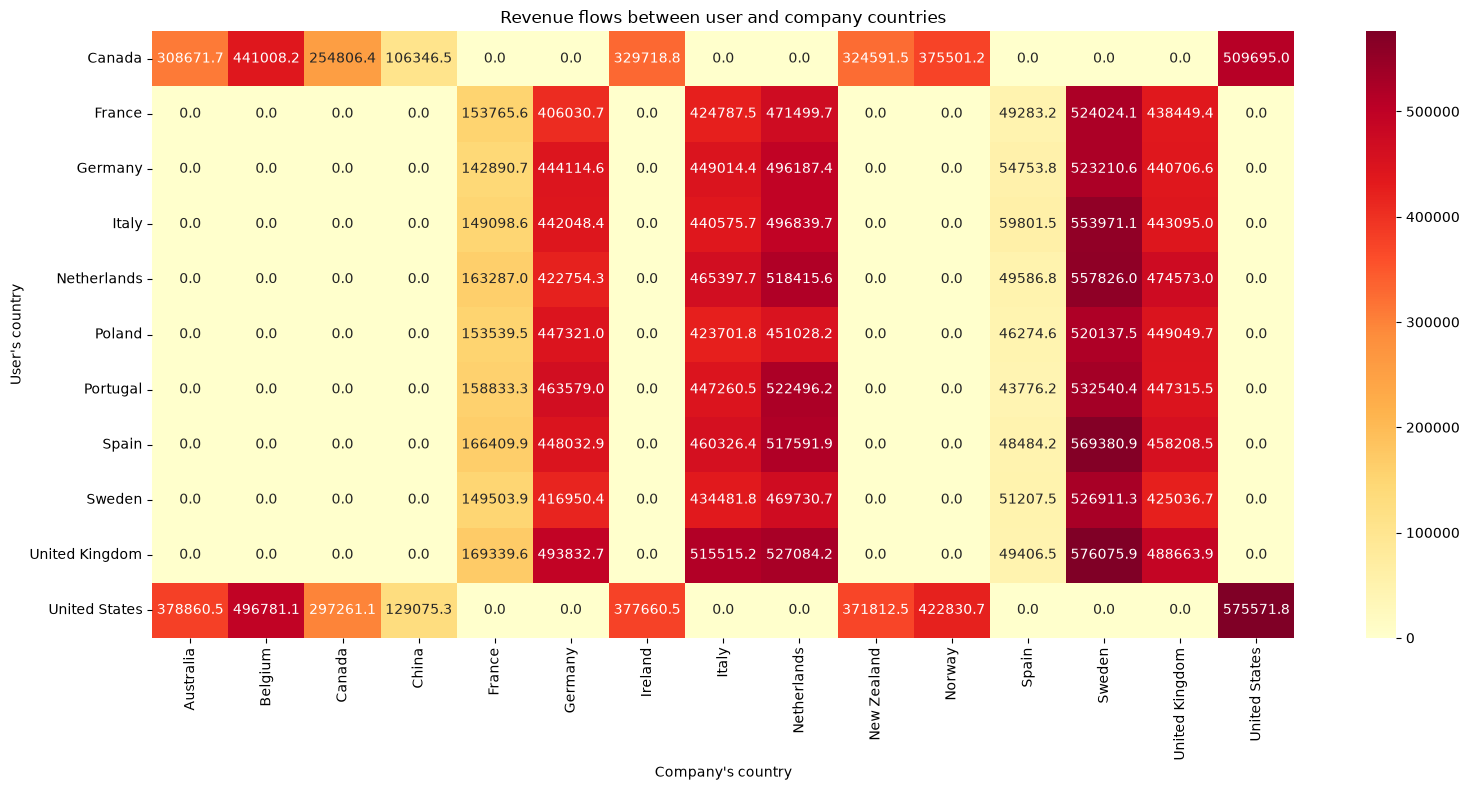

In [80]:
plt.figure(figsize=(16,8))

sns.heatmap(
    cross_country_revenue_flows,
    cmap="YlOrRd",
    annot=True,
    fmt=".1f"
)

plt.title("Revenue flows between user and company countries")
plt.xlabel("Company's country")
plt.ylabel("User's country")

plt.tight_layout()
plt.show()

1. En qué países valdría la pena abrir más compañías locales?

Portugal, Polonia y España presentan una clara oportunidad para ampliar la red de compañías locales, ya que prácticamente toda la demanda se está cubriendo mediante empresas de otros países. Ésto sugiere que existe mercado suficiente para justificar una expansión local.

2. Hay países con demanda pero poca oferta local?

Sí, por ejemplo, Portugal, España, y Polonia, donde existe un alto volumen de facturación pero su totalidad (o la práctica totalidad) se factura en una compañía internacional. Ésto significa que los usuarios compran mucho, pero no a compañías locales, y la demanda se acaba cubriendo internacionalmente.

3. El negocio depende demasiado de compañías de un solo país?

No, la facturación está bastante repartida, si bien vimos anteriormente que cerca de 75% de la facturación se concentra en cinco de los quince países.

4. Abrir compañías locales reduciría fricción o mejoraría la conversión?

La elevada proporción de compras internacionales en países como España, Portugal o Polonia sugiere que la apertura de compañías locales podría reducir costes logísticos, disminuir tiempos de entrega y mejorar la experiencia del cliente, favoreciendo potencialmente una mayor conversión.

Con los datos disponibles, la estrategia más razonable sería priorizar la apertura de compañías en Portugal, Polonia y España, ya que combinan una elevada demanda con una presencia prácticamente inexistente de oferta local. Al mismo tiempo, el negocio no parece depender excesivamente de un único país vendedor, ya que la facturación está distribuida entre varios mercados europeos y Estados Unidos. Por último, el predominio de compras internacionales en determinados países indica que reforzar la oferta local podría reducir la distancia media de envío, mejorar la experiencia del cliente y favorecer un incremento de la conversión y la fidelización.

################################################################

# 5. Análisis ejecutivo de Ventas

Una vez realizados los análisis anteriores, la dirección comercial necesita una visión resumida que permita monitorizar rápidamente el estado del negocio.

El objetivo es construir una herramienta de seguimiento orientada al departamento de Ventas / Comercial, capaz de sintetizar los principales indicadores y patrones detectados durante el análisis.

El dashboard debe permitir responder rápidamente preguntas como:

*   ¿Cuál es el volumen actual de facturación?
*   ¿Cuántas transacciones se realizan?
*   ¿Cuántos clientes están activos?
*   ¿Cuál es el valor medio de una transacción?
*   ¿Cómo evoluciona la actividad comercial?
*   ¿Qué mercados concentran la facturación?
*   ¿Qué productos tienen mayor peso?
*   ¿Cuántos clientes presentan señales de inactividad?

La prioridad será que las métricas y visualizaciones sean claras, relevantes y coherentes con las necesidades del departamento, no que sean técnicamente complejas.

¿Cuál es la situación actual del negocio comercial, dónde están los principales riesgos y qué áreas presentan oportunidades de crecimiento?

In [81]:
# Función para extraer la facturación por producto y el total de ventas para quedarnos con el Top 15 de productos

def products_turnover(df_transactions_products, df_products):

    df_transactions_products = df_transactions_products.merge(
        df_products[["id", "price"]].rename(columns={"id":"product_id"}),
        on="product_id",
        how="left"
    )

    df_transactions_products = (
        df_transactions_products
        .groupby("product_id")
        .agg(
            total_turnover=("price", "sum"),
            sales=("product_id", "count")
        )
        .nlargest(15, "total_turnover")
    )

    df_transactions_products = (
        df_transactions_products
        .reset_index()
        .merge(
            df_products[["id", "product_name", "category"]].rename(columns={"id":"product_id"}),
            left_on="product_id",
            right_on="product_id",
            how="left"
        )
    )

    return df_transactions_products

In [82]:
# Función para extraer el número de transacciones por mes

def transactions_month(df_transactions):

    df_transactions["year_month"] = (
        df_transactions["timestamp"]
        .dt.to_period("M")
        .astype(str)
    )

    df_transactions_month = (
        df_transactions
        .groupby("year_month")
        .agg(total_transactions=("id", "count"))
        .reset_index()
    )

    return df_transactions_month

In [83]:
# Función para calcular la facturación por compañía

def countries_turnover(df_transactions, df_companies):

    df_country_turnover = df_transactions.merge(
        df_companies,
        left_on='business_id',
        right_on='company_id',
        how="left"
    )

    df_country_turnover = (
        df_country_turnover
        .groupby('country')
        .agg(
            total_turnover=('amount','sum')
        )
        .sort_values(
            by='total_turnover',
            ascending=False
        )
    )

    df_country_turnover['total_percent'] = (
        df_country_turnover['total_turnover'] /
        df_country_turnover['total_turnover'].sum()
        * 100
    )

    df_country_turnover["pareto"] = (
        100
        * df_country_turnover["total_percent"].cumsum()
        / df_country_turnover["total_percent"].sum()
    )

    return df_country_turnover

In [84]:
# Función para calcular los días que lleva sin comprar cada usuario

def days_without_buying(df_transactions):

    last_purchase = (
        df_transactions
        .groupby("user_id")["timestamp"]
        .max()
    )

    reference_date = last_purchase.max()

    df_days_without_buying = (
        pd.DataFrame({
            "days_without_buying":
            (reference_date - last_purchase).dt.days
        })
        .reset_index()
    )

    return df_days_without_buying


In [85]:
# Función que agrupa las funciones anteriores y crea los dashboards

def create_dashboard(
    df_transactions, df_products, df_companies, year_min, year_max
):

    df = df_transactions[
        (df_transactions["year"] >= year_min)
        & (df_transactions["year"] <= year_max)
        & (df_transactions["declined"] == 0)
    ].copy()

    # KPIs
    turnover = df["amount"].sum()
    transactions = len(df)
    customers = df["user_id"].nunique()
    average_ticket = df["amount"].mean()

    df_transactions_products = explode_transactions(df)

    df_products_turnover = products_turnover(
        df_transactions_products, df_products
    )

    df_transactions_month = transactions_month(df)

    df_country_turnover = countries_turnover(df, df_companies)

    df_days_without_buying = days_without_buying(df_transactions)

    # Definición de subplots con secondary_y habilitado para Pareto
    fig = make_subplots(
        rows=3,
        cols=4,
        row_heights=[0.18, 0.41, 0.41],
        specs=[
            [
                {"type": "indicator"},
                {"type": "indicator"},
                {"type": "indicator"},
                {"type": "indicator"},
            ],
            [
                {"type": "xy", "colspan": 2},
                None,
                {"type": "xy", "colspan": 2, "secondary_y": True},
                None,
            ],
            [
                {"type": "xy", "colspan": 2},
                None,
                {"type": "xy", "colspan": 2},
                None,
            ],
        ],
        subplot_titles=(
            "",
            "",
            "",
            "",
            "Monthly evolution",
            "Turnover by country (Pareto)",
            "Top 15 products",
            "Inactive users",
        ),
    )

    # Indicadores
    TITLE_FONT_SIZE = 20
    NUMBER_FONT_SIZE = 32

    fig.add_trace(
        go.Indicator(
            mode="number",
            value=turnover,
            title={"text": "Turnover", "font": {"size": TITLE_FONT_SIZE}},
            number={"prefix": "€", "valueformat": ",.0f", "font": {"size": NUMBER_FONT_SIZE}},
        ),
        row=1, col=1
    )

    fig.add_trace(
        go.Indicator(
            mode="number",
            value=transactions,
            title={"text": "Transactions", "font": {"size": TITLE_FONT_SIZE}},
            number={"valueformat": ",", "font": {"size": NUMBER_FONT_SIZE}},
        ),
        row=1, col=2
    )

    fig.add_trace(
        go.Indicator(
            mode="number",
            value=customers,
            title={"text": "Customers", "font": {"size": TITLE_FONT_SIZE}},
            number={"valueformat": ",", "font": {"size": NUMBER_FONT_SIZE}},
        ),
        row=1, col=3
    )

    fig.add_trace(
        go.Indicator(
            mode="number",
            value=average_ticket,
            title={"text": "Average ticket", "font": {"size": TITLE_FONT_SIZE}},
            number={"prefix": "€", "valueformat": ".2f", "font": {"size": NUMBER_FONT_SIZE}},
        ),
        row=1, col=4
    )

    # Evolucion mensual (Fila 2, Columna 1)
    fig.add_trace(
        go.Scatter(
            x=df_transactions_month["year_month"],
            y=df_transactions_month["total_transactions"],
            mode="lines",
            name="Transactions",
        ),
        row=2,
        col=1,
    )

    # Gráfico de Pareto (Fila 2, Columna 3)
    fig.add_trace(
        go.Bar(
            x=df_country_turnover.index,
            y=df_country_turnover["total_turnover"],
            name="Turnover",
        ),
        row=2,
        col=3,
    )

    fig.add_trace(
        go.Scatter(
            x=df_country_turnover.index,
            y=df_country_turnover["pareto"],
            mode="lines+markers",
            name="Pareto",
        ),
        row=2,
        col=3,
        secondary_y=True,
    )

    # Top 15 Productos (Fila 3, Columna 1)
    df_top_15 = df_products_turnover.sort_values(by="total_turnover", ascending=True)

    fig.add_trace(
        go.Bar(
            x=df_top_15["total_turnover"],
            y=df_top_15["product_name"],
            orientation="h",
            name="Products",
        ),
        row=3,
        col=1,
    )

    # Usuarios inactivos (Fila 3, Columna 3)
    fig.add_trace(
        go.Histogram(
            x=df_days_without_buying["days_without_buying"],
            nbinsx=40,
            name="Inactive",
        ),
        row=3,
        col=3,
    )

    # Layout
    fig.update_layout(
        height=900,
        width=1400,
        template="plotly_white",
        title="<b>Sales Dashboard</b>",
        showlegend=False,
    )

    fig.update_yaxes(
        title="Turnover (€)", row=2, col=3, secondary_y=False
    )
    fig.update_yaxes(
        title="Pareto (%)", row=2, col=3, secondary_y=True
    )

    fig.show()

In [86]:
# Añadimos un slider que actualice los datos con la franja de años que queramos analizar

slider = widgets.SelectionRangeSlider(
    options=sorted(df_transactions["year"].unique()),
    value=(2015, 2024),
    description="Years",
    continuous_update=False,
    layout=widgets.Layout(width="900px"),
)

In [87]:
def update(range):

    create_dashboard(
        df_transactions,
        df_products,
        df_companies,
        range[0],
        range[1]
    )

In [88]:
out = widgets.interactive_output(update, {"range": slider})

widgets.interactive_output(
    update,
    {"range": slider}
)

display(slider, out)

SelectionRangeSlider(continuous_update=False, description='Years', index=(0, 9), layout=Layout(width='900px'),…

Output()

################################################################

# 6. Informe ejecutivo

Finalmente, la dirección necesita convertir los resultados del análisis en un informe ejecutivo que facilite la toma de decisiones.

Hemos creado un dashboard para el equipo de Ventas donde a primera vista podemos ver los principales cuatro KPIs para el equipo (facturación, Nº de transacciones, Nº de clientes, y media de gasto por transacción). También vemos la evolución mensual del número de ventas, la facturación por país con su porcentaje con respecto a la facturación total, los 15 productos con mayor facturación, y la cantidad de usuarios inactivos y los días que llevan sin comprar. Esto nos da una visión general del estado de las ventas a lo largo del tiempo para detectar patrones estacionales, ver si dependemos excesivamente de un mercado específico, los productos que más facturación nos generan, y finalmente, el gráfico con los usuarios inactivos para generar estrategias de ventas de reenganche.

Al analizar la evolución mensual se observa una elevada variabilidad entre meses, con numerosos picos y descensos a lo largo de toda la serie temporal. Sabemos por los mapas de calor que existe cierta estacionalidad donde el mes de enero suele presentar un volumen de facturación bajo, mientras que febrero y octubre suele presentar una facturación generalmente mayor. También, dependemos en exceso de cinco mercados principales (Suecia, Países Bajos, Reino Unido, Italia y Alemania) que generan cerca del 75% de la facturación, y finalmente, tenemos una ventana de oportunidad de repescar clientes que llevan inactivos un periodo de tiempo razonable.

Uno de los principales riesgos detectados es la elevada dependencia de un número reducido de mercados. Desde el punto de vista del negocio, esto supone un riesgo, ya que cualquier cambio económico, regulatorio o competitivo en alguno de estos países podría tener un impacto significativo sobre los ingresos globales. También hemos detectado que la facturación depende excesivamente de una base de usuarios recurrentes, lo que supone un riesgo a largo plazo debido a que no entran muchos usuarios nuevos. Si la captación de nuevos usuarios es baja, el crecimiento futuro depende de conservar a los actuales clientes.

Una de las principales oportunidades nace de expandirse a mercados que generan un alto volumen de facturación en mercados internacionales pero bajo a nivel nacional. De esta manera no seremos tan dependientes de un número reducido de mercados y menos susceptibles a posibles cambios regulatorios o económicos. También podemos monitorizar los usuarios inactivos y los días que están sin comprar para generar campañas dirigidas.

Como recomendaciones, teniendo en cuenta el análisis de dependencia geográfica, sería recomendable diversificar la actividad comercial, orientándolo a aquellos países que generan un alto volumen de facturación en mercados internacionales pero bajo a nivel nacional, como por ejemplo, Portugal, Polonia y España. También sería recomendable implementar estrategias de fidelización del cliente, sobretodo hacia aquellos clientes recurrentes, para intentar aumentar la frecuencia de compra. Finalmente planificaremos campañas comerciales durante los periodos de menor actividad para generar un flujo más estable y previsible.

#####

## Informe ejecutivo – Análisis del área de Ventas

### 1. Resumen general

Se ha construido un dashboard orientado al equipo de Ventas para analizar la evolución y el comportamiento de la actividad comercial. El análisis incluye los principales KPIs de facturación, transacciones, clientes y ticket medio, así como la evolución temporal de las ventas, la distribución de la facturación por país, los productos con mayor facturación y los usuarios inactivos. El objetivo es detectar patrones de comportamiento, riesgos de concentración y oportunidades de crecimiento y fidelización.

### 2. Hallazgos clave

* La evolución mensual de las transacciones presenta una elevada variabilidad, con numerosos picos y descensos a lo largo del periodo analizado. Además, el análisis temporal muestra cierta estacionalidad, con niveles generalmente más bajos en enero y superiores en febrero y octubre.

* Existe una elevada concentración geográfica de la facturación. Suecia, Países Bajos, Reino Unido, Italia y Alemania acumulan aproximadamente el 75 % de la facturación total, lo que evidencia una dependencia significativa de un número reducido de mercados.

* Una parte importante de la actividad comercial procede de usuarios recurrentes. La baja captación de nuevos usuarios supone un riesgo para el crecimiento futuro, ya que aumenta la dependencia de la capacidad de mantener activa la base actual de clientes.

* Existen usuarios que llevan un periodo prolongado sin realizar compras. Este segmento representa una oportunidad para desarrollar acciones de reactivación y recuperar parte de la actividad comercial perdida.

* Los mercados de Portugal, Polonia y España presentan una oportunidad potencial de expansión local, ya que existe una demanda significativa procedente de usuarios de estos países mientras la presencia de compañías locales es inexistente o reducida.

### 3. Riesgos detectados

El principal riesgo identificado es la elevada dependencia de un número reducido de mercados. Cualquier cambio económico, regulatorio o competitivo que afectase significativamente a Suecia, Países Bajos, Reino Unido, Italia o Alemania podría repercutir de forma importante sobre los ingresos globales.

También existe un riesgo asociado a la dependencia de usuarios recurrentes. Si la captación de nuevos clientes continúa siendo limitada, el crecimiento futuro dependerá principalmente de mantener activa la base de usuarios existente.

Por último, la variabilidad observada en el volumen mensual de ventas puede dificultar la previsibilidad de los ingresos y la planificación comercial.

### 4. Oportunidades

Una de las principales oportunidades consiste en desarrollar la presencia comercial en mercados donde existe demanda internacional pero una oferta local limitada. Portugal, Polonia y España destacan especialmente en este sentido y podrían analizarse como posibles mercados para ampliar la presencia de compañías locales.

También existe una oportunidad de recuperar usuarios inactivos mediante campañas de reactivación segmentadas según el tiempo transcurrido desde su última compra.

La existencia de cierta estacionalidad permite, además, anticipar periodos de menor actividad y planificar acciones comerciales específicas para reducir las fluctuaciones del volumen de ventas.

### 5. Recomendaciones

1. **Diversificar geográficamente la actividad comercial**, priorizando el análisis de mercados con elevada demanda internacional y poca presencia de compañías locales, con el objetivo de reducir la dependencia de los cinco principales mercados actuales.

2. **Implementar estrategias de fidelización** dirigidas a los usuarios recurrentes para aumentar la frecuencia de compra y reducir el riesgo de pérdida de clientes.

3. **Crear campañas de reactivación segmentadas** para usuarios inactivos, diferenciando las acciones según el tiempo transcurrido desde su última compra y evitando aplicar una estrategia comercial indiscriminada.

4. **Planificar campañas comerciales de forma estacional**, reforzando las acciones durante los periodos de menor actividad para conseguir una evolución más estable y previsible del volumen de ventas.

5. **Monitorizar periódicamente los principales KPIs comerciales** —facturación, transacciones, clientes y ticket medio— para evaluar la evolución de estas estrategias y detectar rápidamente cambios relevantes en el comportamiento de los clientes o en la concentración geográfica de los ingresos.

En conjunto, la estrategia debería orientarse a **diversificar los mercados, aumentar la captación y fidelización de usuarios y mejorar la previsibilidad del volumen de ventas**, reduciendo progresivamente la dependencia de un número reducido de mercados y de la base actual de clientes.
